# S3 — CMIP6 Köppen proxy zone assignment / CMIP6 Köppen代理分区

This notebook assigns a Köppen-based proxy zone to every S2 land cell. The external 0.1° Köppen–Geiger raster is aggregated to the CMIP grid using cos(latitude)-weighted area fractions. Non-ice land cells receive one of four proxy zones (WW, WD, CW, CD); land-ice cells are labelled LI; cells whose ice status is unknown are labelled `ice_status_unknown`. No relationship fitting or classification is performed here — that belongs in S4.

**中文说明：** 本Notebook为S2的每个陆地格点分配基于Köppen的代理分区。0.1°Köppen–Geiger栅格通过cos(纬度)面积加权聚合到CMIP网格。非冰陆地格点分入WW、WD、CW、CD四区之一；陆地冰格点标记为LI；冰况未知的格点标记为`ice_status_unknown`。本步骤不做关系拟合或分类——那些属于S4。

## 1. Configuration / 配置

Locate S2 land products and the external Köppen raster. Configuration mirrors S2: model list, experiment, and period are explicit. The four-zone proxy mapping is documented in the table below and frozen for this analysis.

**中文说明：** 自动定位S2的陆地产品和外部Köppen文件。四区代理映射在此冻结，不会看到结果后再调整。

In [21]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap

warnings.filterwarnings('ignore', category=FutureWarning)


def locate_case_dir() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / 'cmip_utils.py').exists() and candidate.name == 'caseA':
            return candidate
        nested = candidate / 'case' / 'caseA'
        if (nested / 'cmip_utils.py').exists():
            return nested
    raise FileNotFoundError('Could not locate case/caseA/cmip_utils.py')


CASE_DIR = locate_case_dir()
DATA_ROOT = Path('/Volumes/mimi-T9/CMIP6')
KG_PATH = CASE_DIR / 'koppen_geiger_0p1.nc'

MODELS = [
    'CESM2', 'CNRM-CM6-1', 'CanESM5', 'E3SM-1-0', 'GFDL-CM4',
    'IPSL-CM6A-LR', 'MIROC-ES2H', 'MRI-ESM2-0',
    'CMCC-CM2-SR5', 'FGOALS-g3', 'NorESM2-LM',
]
EXPERIMENTS = ['historical']
START_YEAR = 1985
END_YEAR = 2014
MIN_PURITY_FOR_CORE = 0.60
MIN_COVERAGE_FOR_CORE = 0.50
WRITE_OUTPUTS = True
PROCESSING_VERSION = 'S3-zones-v1'

ZONE_ORDER = ['WW', 'WD', 'CW', 'CD']
ANALYSIS_ZONE_ALL = ['WW', 'WD', 'CW', 'CD', 'LI', 'EF', 'ice_status_unknown', 'KG_unclassified']
ZONE_LABELS = {
    'WW': 'Warm–Wet', 'WD': 'Warm–Dry',
    'CW': 'Cold–Wet', 'CD': 'Cold–Dry',
    'LI': 'Land Ice',
    'EF': 'EF (non-ice, Köppen EF)',
    'ice_status_unknown': 'Ice status unknown',
    'KG_unclassified': 'Unclassified',
}
ZONE_COLORS = {
    'WW': '#078C78', 'WD': '#A85F12',
    'CW': '#73C9C2', 'CD': '#DFC27D',
    'LI': '#5B7DA8',
    'EF': '#8B6CAF',
    'ice_status_unknown': '#9CA3AF',
    'KG_unclassified': '#D1D5DB',
}

KOPPEN_LABELS = {
    0: 'Ocean/None',
    1: 'Af', 2: 'Am', 3: 'Aw', 4: 'BWh', 5: 'BWk', 6: 'BSh', 7: 'BSk',
    8: 'Csa', 9: 'Csb', 10: 'Csc', 11: 'Cwa', 12: 'Cwb', 13: 'Cwc',
    14: 'Cfa', 15: 'Cfb', 16: 'Cfc', 17: 'Dsa', 18: 'Dsb', 19: 'Dsc',
    20: 'Dsd', 21: 'Dwa', 22: 'Dwb', 23: 'Dwc', 24: 'Dwd', 25: 'Dfa',
    26: 'Dfb', 27: 'Dfc', 28: 'Dfd', 29: 'ET', 30: 'EF',
}
KOPPEN_MAJOR = {
    1: 'A', 2: 'A', 3: 'A',
    4: 'B', 5: 'B', 6: 'B', 7: 'B',
    8: 'C', 9: 'C', 10: 'C', 11: 'C', 12: 'C', 13: 'C', 14: 'C', 15: 'C', 16: 'C',
    17: 'D', 18: 'D', 19: 'D', 20: 'D', 21: 'D', 22: 'D', 23: 'D', 24: 'D',
    25: 'D', 26: 'D', 27: 'D', 28: 'D',
    29: 'E', 30: 'E',
}
KOPPEN_TO_ZONE = {
    **{code: 'WW' for code in [1, 2, 11, 12, 14, 15]},
    **{code: 'WD' for code in [3, 4, 6, 8, 9]},
    **{code: 'CW' for code in [16, 25, 26, 27, 28, 29]},
    **{code: 'CD' for code in [5, 7, 10, 13, 17, 18, 19, 20, 21, 22, 23, 24]},
}

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 220,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'axes.edgecolor': '#30343B',
    'axes.linewidth': 0.9, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

if not KG_PATH.exists():
    raise FileNotFoundError(f'Köppen raster not found: {KG_PATH}')

print(f'Case directory: {CASE_DIR}')
print(f'Data root:      {DATA_ROOT}')
print(f'Köppen raster:  {KG_PATH}')
print(f'Models:         {MODELS}')
print(f'Period:         {START_YEAR}-{END_YEAR}')

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Data root:      /Volumes/mimi-T9/CMIP6
Köppen raster:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/koppen_geiger_0p1.nc
Models:         ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'E3SM-1-0', 'GFDL-CM4', 'IPSL-CM6A-LR', 'MIROC-ES2H', 'MRI-ESM2-0', 'CMCC-CM2-SR5', 'FGOALS-g3', 'NorESM2-LM']
Period:         1985-2014


## 2. Discover S2 land products / 发现S2陆地产品

Find the S2 land climatology and grid-year tables. Each model/experiment/member/grid combination is one independent run.

**中文说明：** 在S2的输出目录中寻找气候态Parquet和年度Parquet。同时加载S2的NetCDF气候态，用于后续空间绘图。

In [22]:
RUNS = []
SKIPPED_MODELS = []
for model in MODELS:
    for experiment in EXPERIMENTS:
        search_root = DATA_ROOT / model / experiment
        clim_name = f'land_climatology_{START_YEAR}_{END_YEAR}.parquet'
        clim_paths = sorted(search_root.glob(f'*/*/land/{clim_name}'))
        if not clim_paths:
            print(f'{model}: no S2 land products found, skipping')
            SKIPPED_MODELS.append(model)
            continue
        for clim_path in clim_paths:
            land_dir = clim_path.parent
            run_root = land_dir.parent
            grid_year_path = land_dir / f'land_grid_year_{START_YEAR}_{END_YEAR}.parquet'
            clim_nc_path = land_dir / f'land_climatology_{START_YEAR}_{END_YEAR}.nc'
            if not grid_year_path.exists():
                print(f'{model}: missing S2 grid-year table, skipping')
                SKIPPED_MODELS.append(model)
                continue
            if not clim_nc_path.exists():
                print(f'{model}: missing S2 climatology NetCDF, skipping')
                SKIPPED_MODELS.append(model)
                continue
            member = run_root.parent.name
            grid = run_root.name
            RUNS.append({
                'model': model,
                'experiment': experiment,
                'member': member,
                'grid': grid,
                'run_root': run_root,
                'land_dir': land_dir,
                'climatology_table_path': clim_path,
                'grid_year_table_path': grid_year_path,
                'climatology_nc_path': clim_nc_path,
            })

INPUT_INVENTORY = pd.DataFrame([{
    'model': r['model'], 'experiment': r['experiment'],
    'member': r['member'], 'grid': r['grid'],
    'clim_rows': len(pd.read_parquet(r['climatology_table_path'])),
    'clim_MB': r['climatology_table_path'].stat().st_size / 1e6,
    'grid_year_MB': r['grid_year_table_path'].stat().st_size / 1e6,
} for r in RUNS])
print(f'\nFound {len(RUNS)} runs, skipped {len(SKIPPED_MODELS)} models: {SKIPPED_MODELS}')
display(INPUT_INVENTORY)

MIROC-ES2H: no S2 land products found, skipping
MRI-ESM2-0: no S2 land products found, skipping

Found 9 runs, skipped 2 models: ['MIROC-ES2H', 'MRI-ESM2-0']


,model,experiment,member,grid,clim_rows,clim_MB,grid_year_MB
0,CESM2,historical,r1i1p1f1,gn,21013,3.859851,89.776563
1,CNRM-CM6-1,historical,r1i1p1f2,gr,13639,2.367103,54.851924
2,CanESM5,historical,r1i1p1f1,gn,3464,0.644951,17.645288
3,E3SM-1-0,historical,r1i1p1f1,gr,27953,5.288567,120.827543
4,GFDL-CM4,historical,r1i1p1f1,gr1,22514,4.095187,92.019317
5,IPSL-CM6A-LR,historical,r1i1p1f1,gr,5638,1.090439,29.860776
6,CMCC-CM2-SR5,historical,r1i1p1f1,gn,20675,3.830040,89.809509
7,FGOALS-g3,historical,r1i1p1f1,gn,5631,1.045428,28.390251
8,NorESM2-LM,historical,r1i1p1f1,gn,5701,0.866896,22.469100


## 3. Audit the Köppen raster / 审计Köppen栅格

Read the 0.1° raster, verify code range and confidence field, and display the four-zone proxy mapping.

**中文说明：** 读入0.1°Köppen栅格，检查编码范围和置信度字段，展示四区代理映射表。

| Proxy zone | Köppen classes | Codes |
|---|---|---|
| WW | Af, Am, Cwa, Cwb, Cfa, Cfb | 1, 2, 11, 12, 14, 15 |
| WD | Aw, BWh, BSh, Csa, Csb | 3, 4, 6, 8, 9 |
| CW | Cfc, Dfa, Dfb, Dfc, Dfd, ET | 16, 25, 26, 27, 28, 29 |
| CD | BWk, BSk, Csc, Cwc, Dsa–Dsd, Dwa–Dwd | 5, 7, 10, 13, 17–24 |
| — | Ocean/none, EF | 0, 30 |

In [23]:
kg_ds = xr.open_dataset(KG_PATH)
kg_classes = kg_ds['kg_class'].values.astype('int16')
kg_confidence = kg_ds['kg_confidence'].values.astype('float32')
kg_lat = kg_ds['lat'].values
kg_lon = kg_ds['lon'].values

audit = pd.Series({
    'latitude_cells': len(kg_lat),
    'longitude_cells': len(kg_lon),
    'min_code': int(kg_classes.min()),
    'max_code': int(kg_classes.max()),
    'min_confidence_pct': float(kg_confidence.min()),
    'max_confidence_pct': float(kg_confidence.max()),
    'codes_in_WW_WD_CW_CD': len(KOPPEN_TO_ZONE),
    'codes_excluded_from_proxy': '0 (Ocean/None), 30 (EF)',
})
display(audit.to_frame('value'))
assert set(np.unique(kg_classes)).issubset(set(range(31)))

,value
latitude_cells,1800
longitude_cells,3600
min_code,0
max_code,30
min_confidence_pct,0.0
max_confidence_pct,100.0
codes_in_WW_WD_CW_CD,29
codes_excluded_from_proxy,"0 (Ocean/None), 30 (EF)"


## 4. Aggregate Köppen to CMIP grid and assign zones / 聚合Köppen到CMIP网格并分配分区

For each run: load the S2 climatology table, build the cos(lat)-weighted area aggregation from the 0.1° raster to the CMIP grid, and assign `analysis_zone` using a four-way decision:

1. `surface_class == land_ice` → `analysis_zone = LI`
2. `surface_class == land_ice_unknown` → `analysis_zone = ice_status_unknown`
3. `surface_class == non_ice_land` and dominant Köppen = EF → `analysis_zone = EF`
4. `surface_class == non_ice_land` and dominant Köppen maps to a proxy zone → `analysis_zone = WW/WD/CW/CD`
5. Anything else (e.g. no valid Köppen coverage) → `analysis_zone = KG_unclassified`

The same function (`_assign_analysis_zone`) is used for both the Parquet table and the NetCDF grid to guarantee consistency.

**中文说明：** 对每个run：加载S2气候态表，用cos(lat)面积加权将0.1° Köppen聚合到CMIP网格，然后按四路判断分配`analysis_zone`。`surface_class`和`koppen_code`作为独立字段保留。`land_ice_unknown`获得单独的`ice_status_unknown`标签而非LI。同一个分区判断函数同时用于Parquet和NetCDF，保证一致性。

In [24]:
ZONE_TO_CODE = {zone: idx for idx, zone in enumerate(ZONE_ORDER, start=1)}
CODE_TO_ZONE = {v: k for k, v in ZONE_TO_CODE.items()}
ANALYSIS_ZONE_CODE_MAP = {
    'WW': 1, 'WD': 2, 'CW': 3, 'CD': 4,
    'LI': 5, 'EF': 6, 'ice_status_unknown': 7, 'KG_unclassified': 8,
}
latitude_weights = np.cos(np.deg2rad(kg_lat))


def _assign_analysis_zone(surface_class_str, dominant_koppen_code, proxy_zone_str):
    """Single decision function used by both table and grid paths."""
    if surface_class_str == 'land_ice':
        return 'LI'
    if surface_class_str == 'land_ice_unknown':
        return 'ice_status_unknown'
    if dominant_koppen_code == 30:
        return 'EF'
    if proxy_zone_str is not None:
        return proxy_zone_str
    return 'KG_unclassified'


def aggregate_koppen_to_grid(cmip_lat, cmip_lon):
    """Area-weighted aggregation of 0.1deg classes to CMIP grid."""
    lat_index = np.abs(kg_lat[:, None] - cmip_lat[None, :]).argmin(axis=1)
    circular_distance = np.abs(((kg_lon[:, None] - cmip_lon[None, :] + 180) % 360) - 180)
    lon_index = circular_distance.argmin(axis=1)

    class_area = np.zeros((len(cmip_lat), len(cmip_lon), 31), dtype='float64')
    confidence_area_sum = np.zeros((len(cmip_lat), len(cmip_lon)), dtype='float64')
    classified_area = np.zeros((len(cmip_lat), len(cmip_lon)), dtype='float64')

    for source_i, target_i in enumerate(lat_index):
        row_classes = kg_classes[source_i]
        valid = (row_classes >= 1) & (row_classes <= 30)
        if not valid.any():
            continue
        target_j = lon_index[valid]
        codes = row_classes[valid]
        pixel_w = np.full(valid.sum(), latitude_weights[source_i])
        np.add.at(class_area[target_i], (target_j, codes), pixel_w)
        np.add.at(classified_area[target_i], target_j, pixel_w)
        np.add.at(confidence_area_sum[target_i], target_j,
                  pixel_w * kg_confidence[source_i, valid])

    group_area = np.zeros((len(cmip_lat), len(cmip_lon), len(ZONE_ORDER)), dtype='float64')
    for code, zone_name in KOPPEN_TO_ZONE.items():
        group_area[:, :, ZONE_TO_CODE[zone_name] - 1] += class_area[:, :, code]

    grouped_area = group_area.sum(axis=2)
    dominant_zone_idx = group_area.argmax(axis=2).astype('int8') + 1
    dominant_zone_idx[grouped_area == 0] = 0

    zone_purity = np.divide(
        group_area.max(axis=2), grouped_area,
        out=np.full_like(grouped_area, np.nan), where=grouped_area > 0,
    )
    kg_grouped_coverage = np.divide(
        grouped_area, classified_area,
        out=np.full_like(grouped_area, np.nan), where=classified_area > 0,
    )
    kg_mean_confidence = np.divide(
        confidence_area_sum, classified_area,
        out=np.full_like(grouped_area, np.nan), where=classified_area > 0,
    )
    dominant_koppen_code = class_area[:, :, 1:].argmax(axis=2).astype('int16') + 1
    dominant_koppen_code[classified_area == 0] = 0

    # per-zone fractions relative to total classified area
    fraction_grids = {}
    for zone_name in ZONE_ORDER:
        zi = ZONE_TO_CODE[zone_name] - 1
        fraction_grids[f'fraction_{zone_name}'] = np.divide(
            group_area[:, :, zi], classified_area,
            out=np.full_like(classified_area, np.nan), where=classified_area > 0,
        )
    # EF fraction
    fraction_grids['fraction_EF'] = np.divide(
        class_area[:, :, 30], classified_area,
        out=np.full_like(classified_area, np.nan), where=classified_area > 0,
    )
    # dominant koppen class fraction
    dominant_fraction = np.zeros_like(classified_area)
    for i in range(len(cmip_lat)):
        for j in range(len(cmip_lon)):
            dc = int(dominant_koppen_code[i, j])
            if dc > 0 and classified_area[i, j] > 0:
                dominant_fraction[i, j] = class_area[i, j, dc] / classified_area[i, j]
            else:
                dominant_fraction[i, j] = np.nan
    fraction_grids['dominant_koppen_fraction'] = dominant_fraction

    return {
        'dominant_zone_idx': dominant_zone_idx,
        'zone_purity': zone_purity,
        'kg_grouped_coverage': kg_grouped_coverage,
        'kg_mean_confidence': kg_mean_confidence,
        'dominant_koppen_code': dominant_koppen_code,
        **fraction_grids,
    }


def assign_zone_to_table(clim_table, agg, cmip_lat, cmip_lon):
    """Join aggregated zone fields to the S2 climatology table."""
    lat_vals = clim_table['lat'].values
    lon_vals = clim_table['lon'].values
    lat_idx = np.abs(lat_vals[:, None] - cmip_lat[None, :]).argmin(axis=1)
    lon_idx = np.abs(((lon_vals[:, None] - cmip_lon[None, :] + 180) % 360) - 180).argmin(axis=1)

    t = clim_table.copy()
    t['dominant_koppen_code'] = agg['dominant_koppen_code'][lat_idx, lon_idx].astype(int)
    t['dominant_koppen_class'] = t['dominant_koppen_code'].map(KOPPEN_LABELS)
    t['koppen_major'] = t['dominant_koppen_code'].map(KOPPEN_MAJOR)
    t['zone_purity'] = agg['zone_purity'][lat_idx, lon_idx]
    t['kg_grouped_coverage'] = agg['kg_grouped_coverage'][lat_idx, lon_idx]
    t['kg_mean_confidence'] = agg['kg_mean_confidence'][lat_idx, lon_idx]
    t['dominant_koppen_fraction'] = agg['dominant_koppen_fraction'][lat_idx, lon_idx]

    for frac_name in ['fraction_WW', 'fraction_WD', 'fraction_CW', 'fraction_CD', 'fraction_EF']:
        t[frac_name] = agg[frac_name][lat_idx, lon_idx]

    t['core_zone_cell'] = (
        (t['zone_purity'] >= MIN_PURITY_FOR_CORE)
        & (t['kg_grouped_coverage'] >= MIN_COVERAGE_FOR_CORE)
    )

    zone_idx_arr = agg['dominant_zone_idx'][lat_idx, lon_idx]
    koppen_proxy = [CODE_TO_ZONE.get(int(c)) for c in zone_idx_arr]

    t['analysis_zone'] = [
        _assign_analysis_zone(sc, dk, kp)
        for sc, dk, kp in zip(t['surface_class'], t['dominant_koppen_code'], koppen_proxy)
    ]
    return t


ZONE_RESULTS = []
for run in RUNS:
    clim_table = pd.read_parquet(run['climatology_table_path'])
    with xr.open_dataset(run['climatology_nc_path']) as ds:
        land_clim_nc = ds.load()
    cmip_lat = land_clim_nc['lat'].values
    cmip_lon = land_clim_nc['lon'].values

    agg = aggregate_koppen_to_grid(cmip_lat, cmip_lon)
    zoned_table = assign_zone_to_table(clim_table, agg, cmip_lat, cmip_lon)

    ZONE_RESULTS.append({
        **run,
        'zoned_table': zoned_table,
        'land_clim_nc': land_clim_nc,
        'agg': agg,
        'cmip_lat': cmip_lat,
        'cmip_lon': cmip_lon,
    })
    print(f"{run['model']} {run['member']} {run['grid']}: "
          f"{len(zoned_table)} land cells zoned")

CESM2 r1i1p1f1 gn: 21013 land cells zoned
CNRM-CM6-1 r1i1p1f2 gr: 13639 land cells zoned
CanESM5 r1i1p1f1 gn: 3464 land cells zoned
E3SM-1-0 r1i1p1f1 gr: 27953 land cells zoned
GFDL-CM4 r1i1p1f1 gr1: 22514 land cells zoned
IPSL-CM6A-LR r1i1p1f1 gr: 5638 land cells zoned
CMCC-CM2-SR5 r1i1p1f1 gn: 20675 land cells zoned
FGOALS-g3 r1i1p1f1 gn: 5631 land cells zoned
NorESM2-LM r1i1p1f1 gn: 5701 land cells zoned


## 5. Zone assignment QC / 分区分配质量检查

Verify that every land cell received an `analysis_zone`. Report the cross-tabulation of `surface_class` vs `analysis_zone`, and a separate cross-tabulation of `surface_class` vs `dominant_koppen_code` to expose the overlap between model ice (sftgif) and Köppen EF.

**中文说明：** 检查每个陆地格点是否都获得了`analysis_zone`。展示两张交叉表：`surface_class × analysis_zone`和`surface_class × dominant_koppen_code`，后者用于诊断模型冰盖与Köppen EF之间的重叠和不一致。

In [25]:
for res in ZONE_RESULTS:
    t = res['zoned_table']
    print(f"=== {res['model']} {res['member']} {res['grid']} ===")
    print()

    # --- cross-tab: surface_class × analysis_zone ---
    print('Cross-tabulation: surface_class × analysis_zone')
    cross_az = pd.crosstab(t['surface_class'], t['analysis_zone'], margins=True)
    display(cross_az)
    print()

    # --- cross-tab: surface_class × dominant_koppen_class ---
    print('Cross-tabulation: surface_class × dominant_koppen_class')
    cross_kg = pd.crosstab(t['surface_class'], t['dominant_koppen_class'], margins=True)
    display(cross_kg)
    print()

    # --- ice–EF overlap summary ---
    li_cells = t.loc[t['surface_class'] == 'land_ice']
    if len(li_cells) > 0:
        print(f'Land-ice cells by dominant Köppen:')
        display(li_cells['dominant_koppen_class'].value_counts().to_frame('count'))
        print()

    non_ice_ef = t.loc[(t['surface_class'] == 'non_ice_land') & (t['dominant_koppen_code'] == 30)]
    print(f'Non-ice land with dominant EF:  {len(non_ice_ef)}')
    print()

    # --- non-ice zone summary ---
    non_ice = t.loc[t['surface_class'] == 'non_ice_land']
    zone_counts = non_ice['analysis_zone'].value_counts().reindex(ZONE_ORDER, fill_value=0)
    zone_summary = pd.DataFrame({
        'grid_cells': zone_counts,
        'median_purity': non_ice.groupby('analysis_zone')['zone_purity'].median().reindex(ZONE_ORDER),
        'p10_purity': non_ice.groupby('analysis_zone')['zone_purity'].quantile(0.10).reindex(ZONE_ORDER),
        'median_coverage': non_ice.groupby('analysis_zone')['kg_grouped_coverage'].median().reindex(ZONE_ORDER),
        'median_confidence': non_ice.groupby('analysis_zone')['kg_mean_confidence'].median().reindex(ZONE_ORDER),
    })
    display(zone_summary.round(3))
    print()

    # --- full analysis_zone counts ---
    all_zones = t['analysis_zone'].value_counts()
    print('All analysis_zone counts:')
    display(all_zones.to_frame('count'))
    print()

    # --- assertions ---
    assert t['analysis_zone'].notna().all(), 'Some cells have no analysis_zone'
    assert not t['analysis_zone'].isin(['']).any(), 'Some cells have empty analysis_zone'
    li_check = t.loc[t['analysis_zone'] == 'LI', 'surface_class']
    assert (li_check == 'land_ice').all(), 'LI zone contains non land_ice cells'
    isu_check = t.loc[t['analysis_zone'] == 'ice_status_unknown', 'surface_class']
    assert (isu_check == 'land_ice_unknown').all() if len(isu_check) > 0 else True, \
        'ice_status_unknown zone contains wrong surface_class'

=== CESM2 r1i1p1f1 gn ===

Cross-tabulation: surface_class × analysis_zone


analysis_zone,CD,CW,EF,KG_unclassified,LI,WD,WW,All
surface_class,,,,,,,,
land_ice,0,0,0,0,7022,0,0,7022
non_ice_land,2325,4642,18,419,0,4177,2410,13991
All,2325,4642,18,419,7022,4177,2410,21013



Cross-tabulation: surface_class × dominant_koppen_class


dominant_koppen_class,Af,Am,Aw,BSh,BSk,BWh,BWk,Cfa,Cfb,Cfc,...,Dsb,Dsc,Dwa,Dwb,Dwc,Dwd,EF,ET,Ocean/None,All
surface_class,,,,,,,,,,,,,,,,,,,,,
land_ice,0,0,0,0,8,0,13,0,14,4,...,6,9,0,2,5,0,6109,717,56,7022
non_ice_land,624,413,1437,659,781,1819,646,581,363,7,...,47,227,108,158,315,43,18,999,419,13991
All,624,413,1437,659,789,1819,659,581,377,11,...,53,236,108,160,320,43,6127,1716,475,21013



Land-ice cells by dominant Köppen:


...

,count
dominant_koppen_class,
EF,1621
ET,253
Dfc,29
Cfb,10
Ocean/None,7
BSk,7
BWk,7
Cwa,5
Dsc,5



Non-ice land with dominant EF:  0



,grid_cells,median_purity,p10_purity,median_coverage,median_confidence
analysis_zone,,,,,
WW,723,1.000,0.659,1.0,84.691
WD,1150,1.000,0.703,1.0,92.768
CW,1229,1.000,0.787,1.0,88.271
CD,592,0.975,0.606,1.0,85.522



All analysis_zone counts:


,count
analysis_zone,
LI,1949
CW,1229
WD,1150
WW,723
CD,592
KG_unclassified,58


## 6. Zone maps / 分区地图

Two maps per run:

1. **Köppen 0.1° proxy reference** — shows the four non-ice proxy zones at full raster resolution, with CMIP-grid ice cells overlaid. This is the source-data reference.
2. **CMIP-grid analysis_zone** — shows the actual zone assignment used in downstream analysis, at CMIP resolution. All zone types are shown (WW, WD, CW, CD, LI, EF, ice_status_unknown, KG_unclassified — though some may have zero cells).

**中文说明：** 每个run输出两张地图：(1) 0.1° Köppen参考图，保留地理边界细节；(2) CMIP网格实际分区图，展示后续分析使用的真实分区。

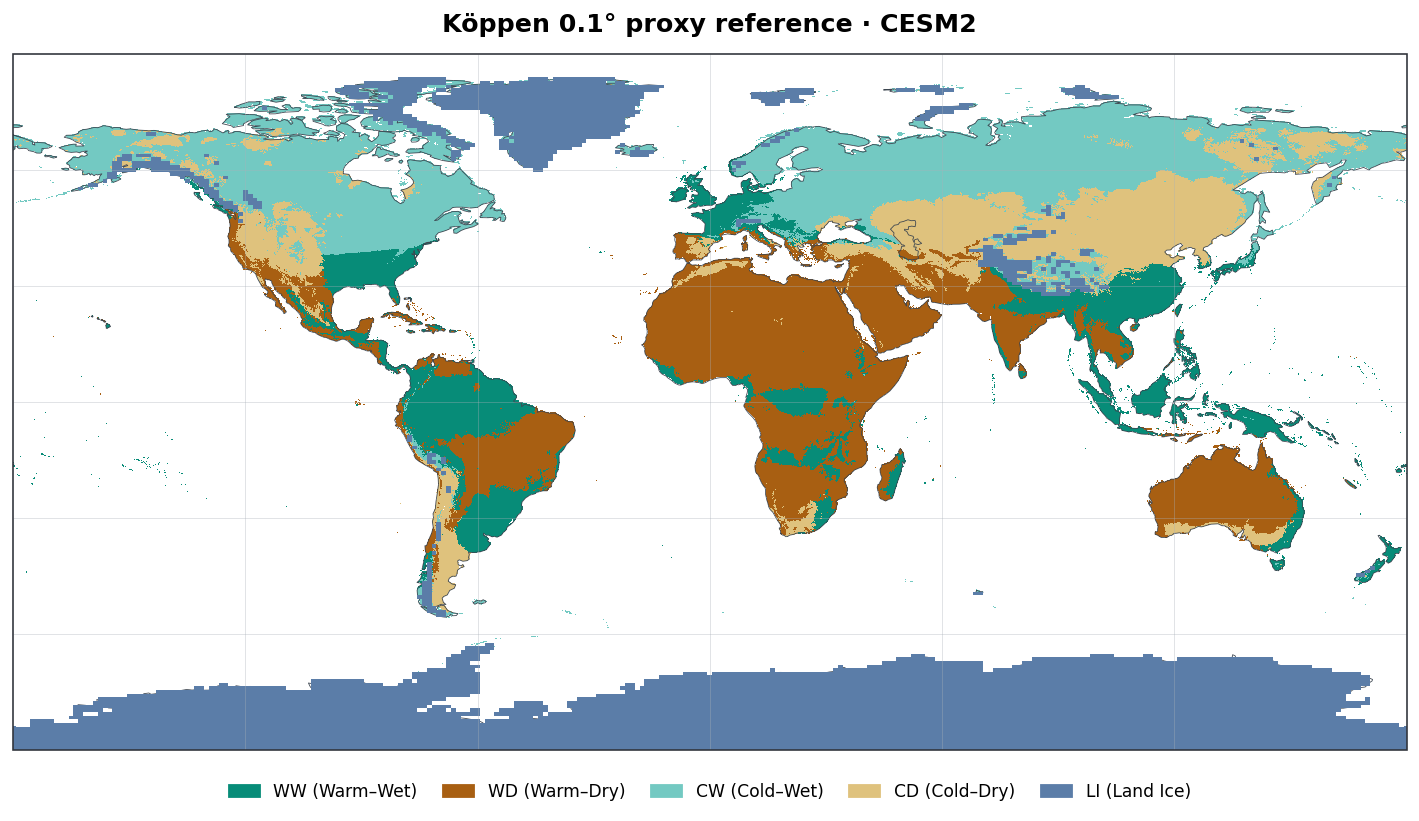

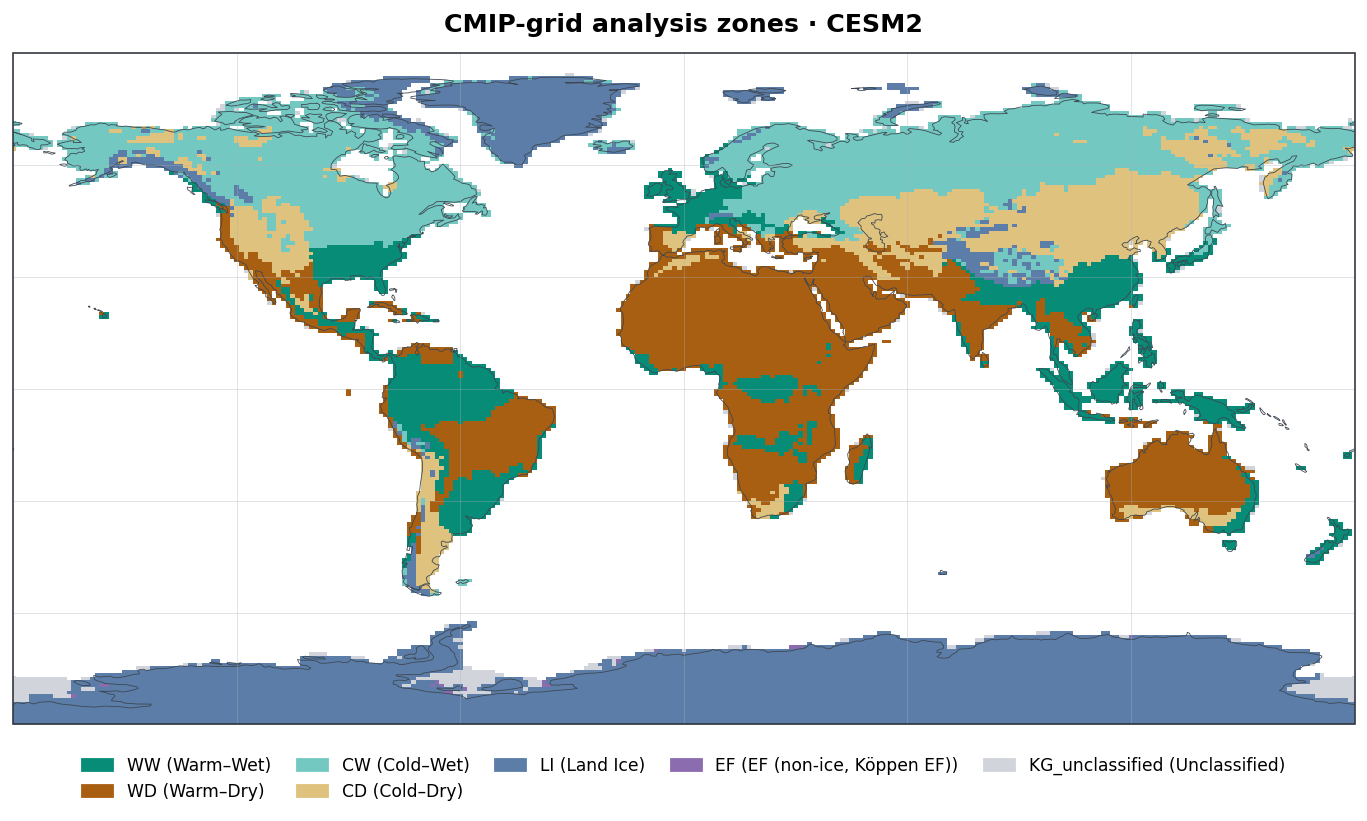

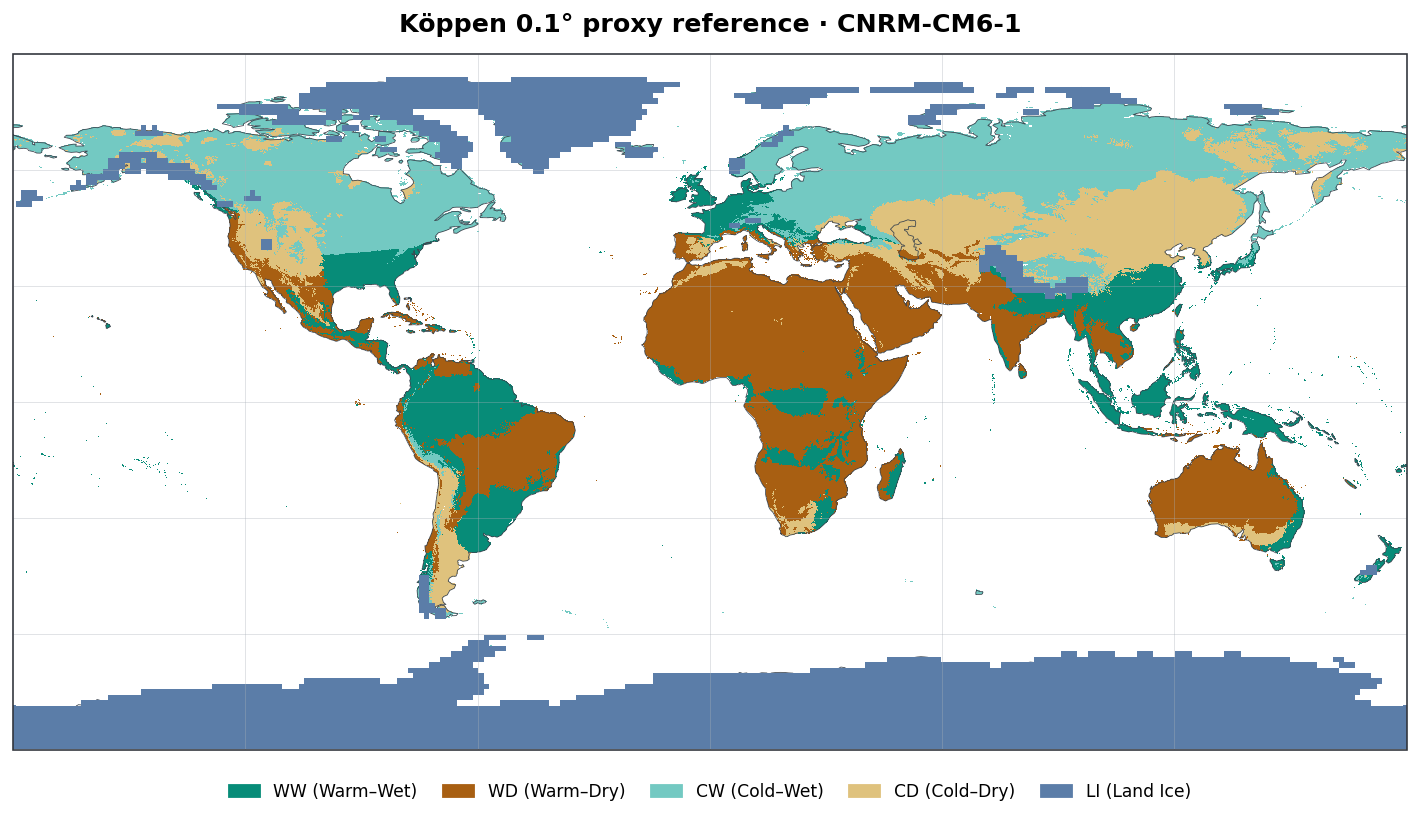

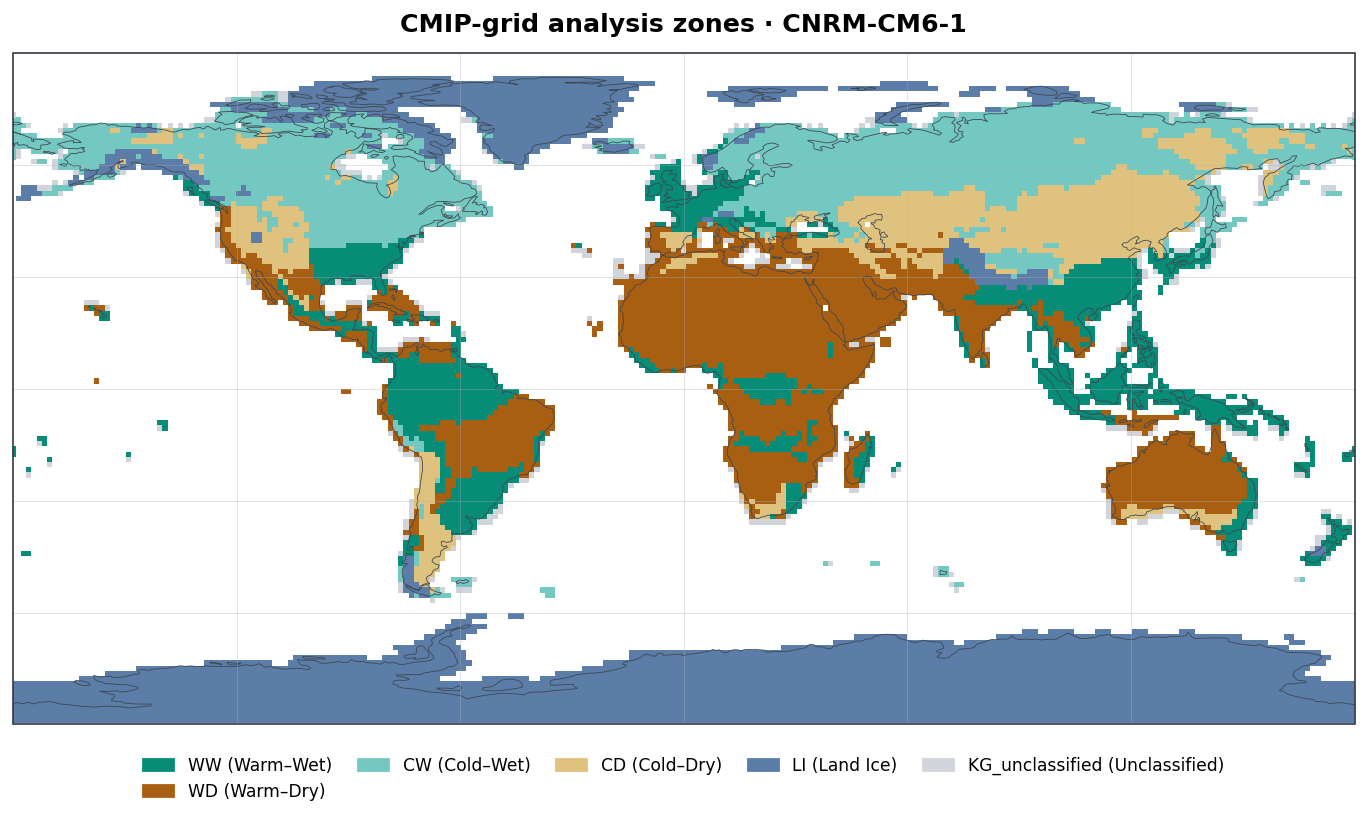

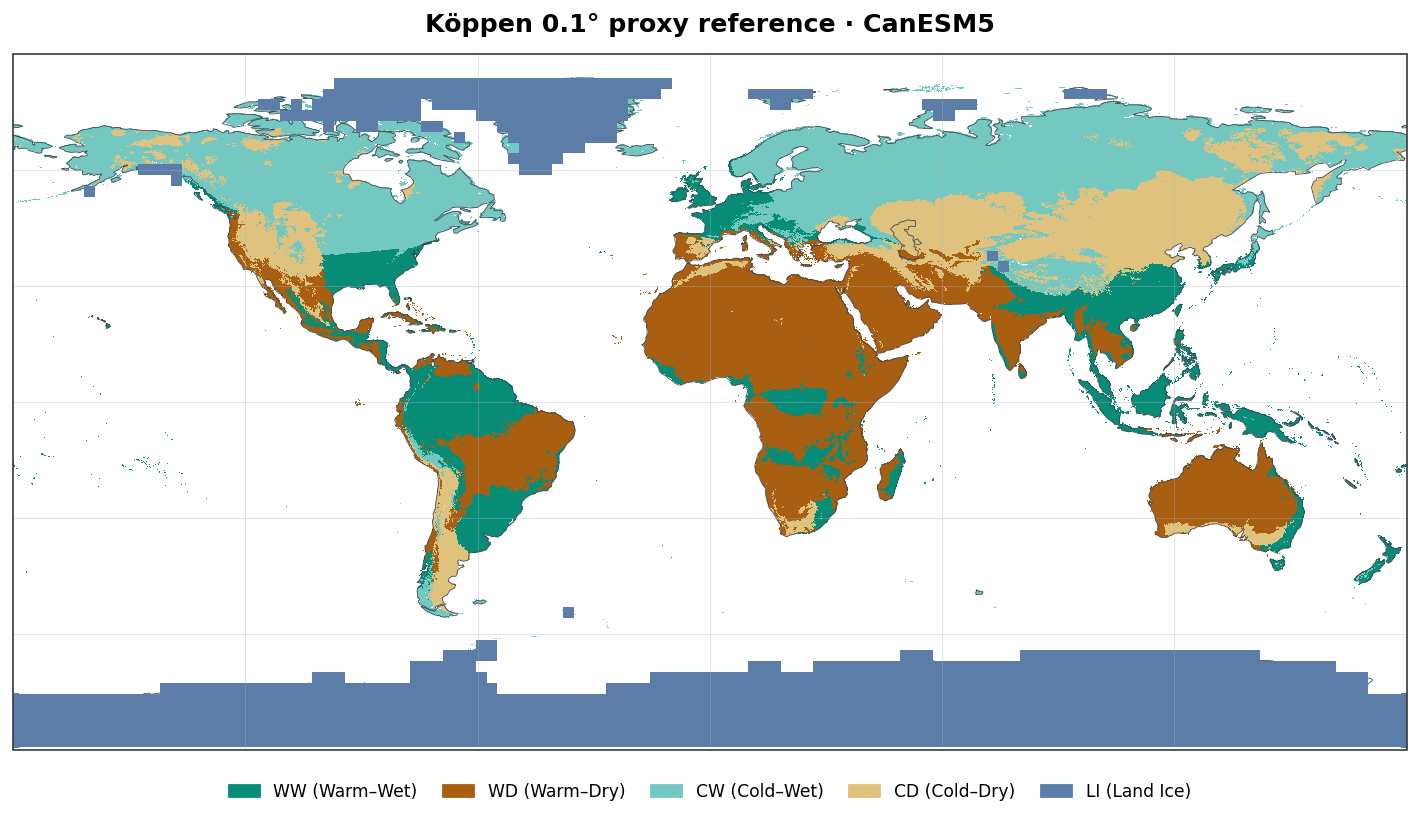

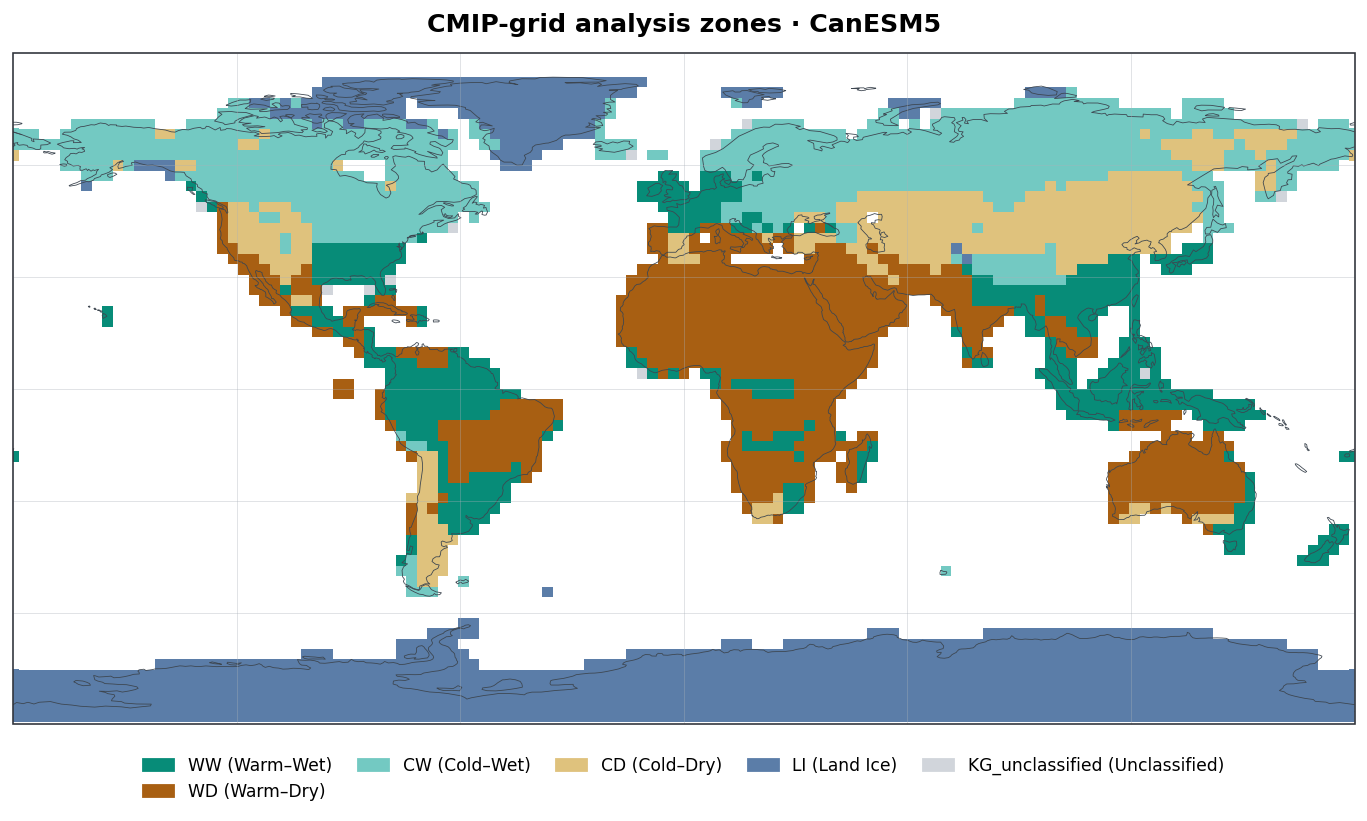

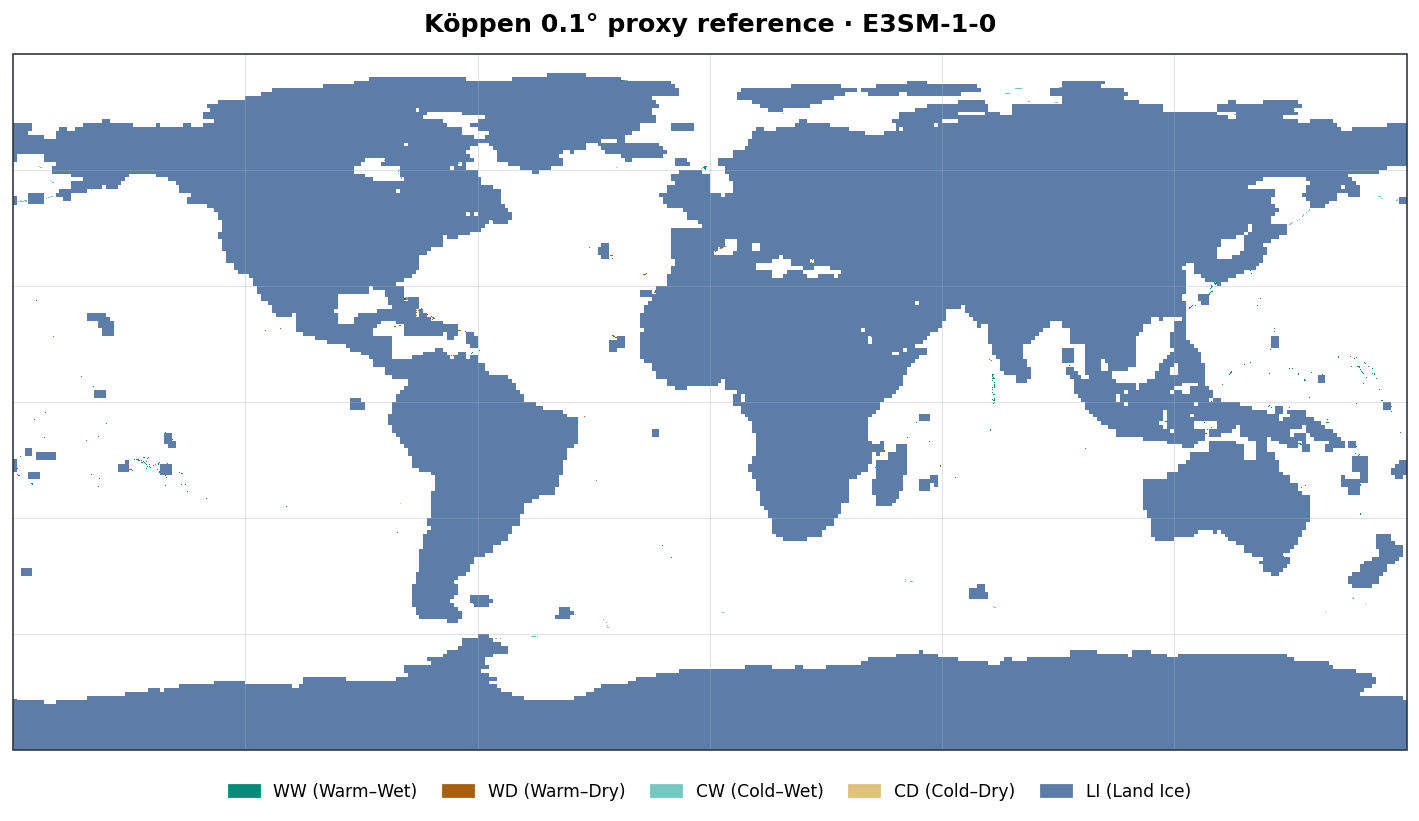

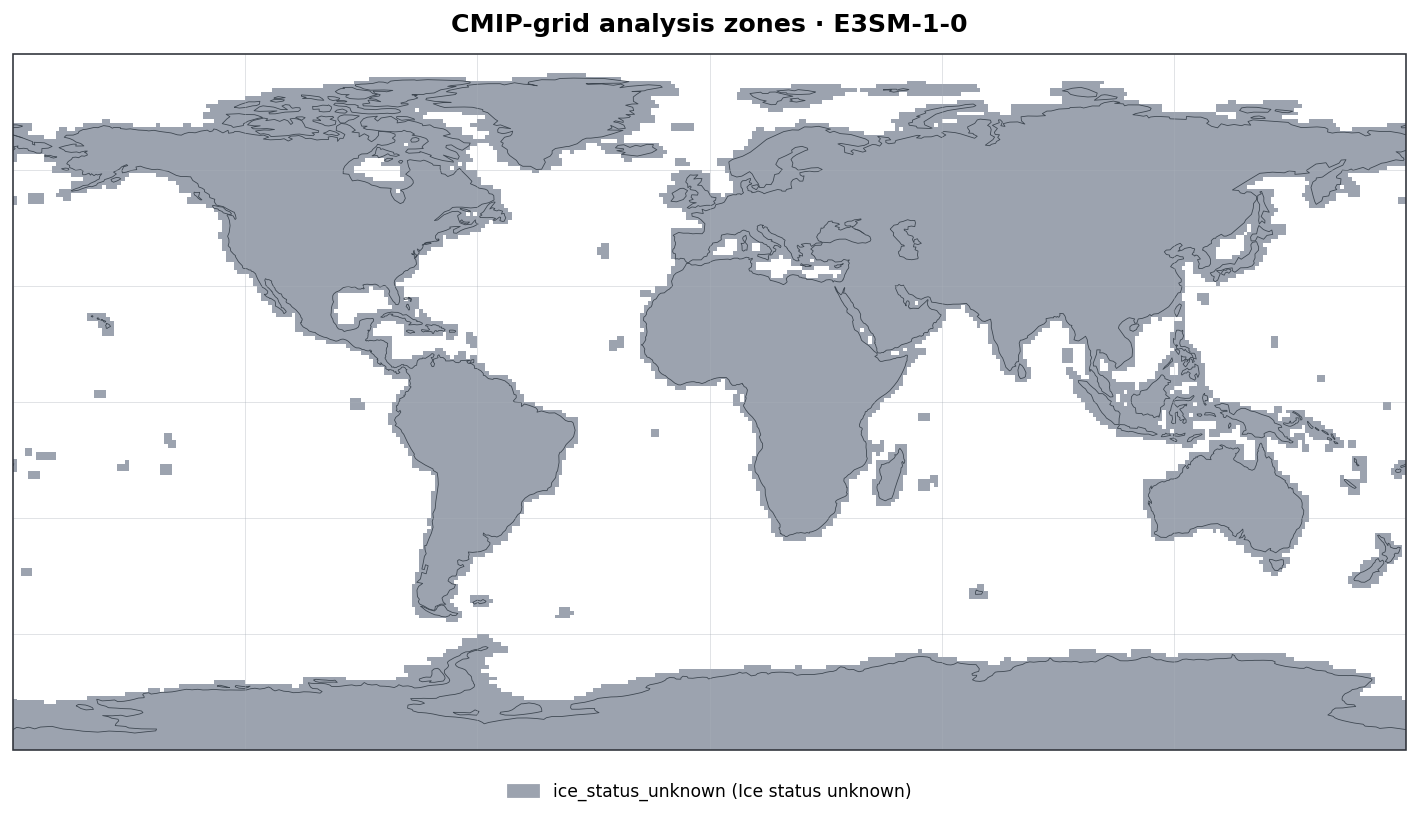

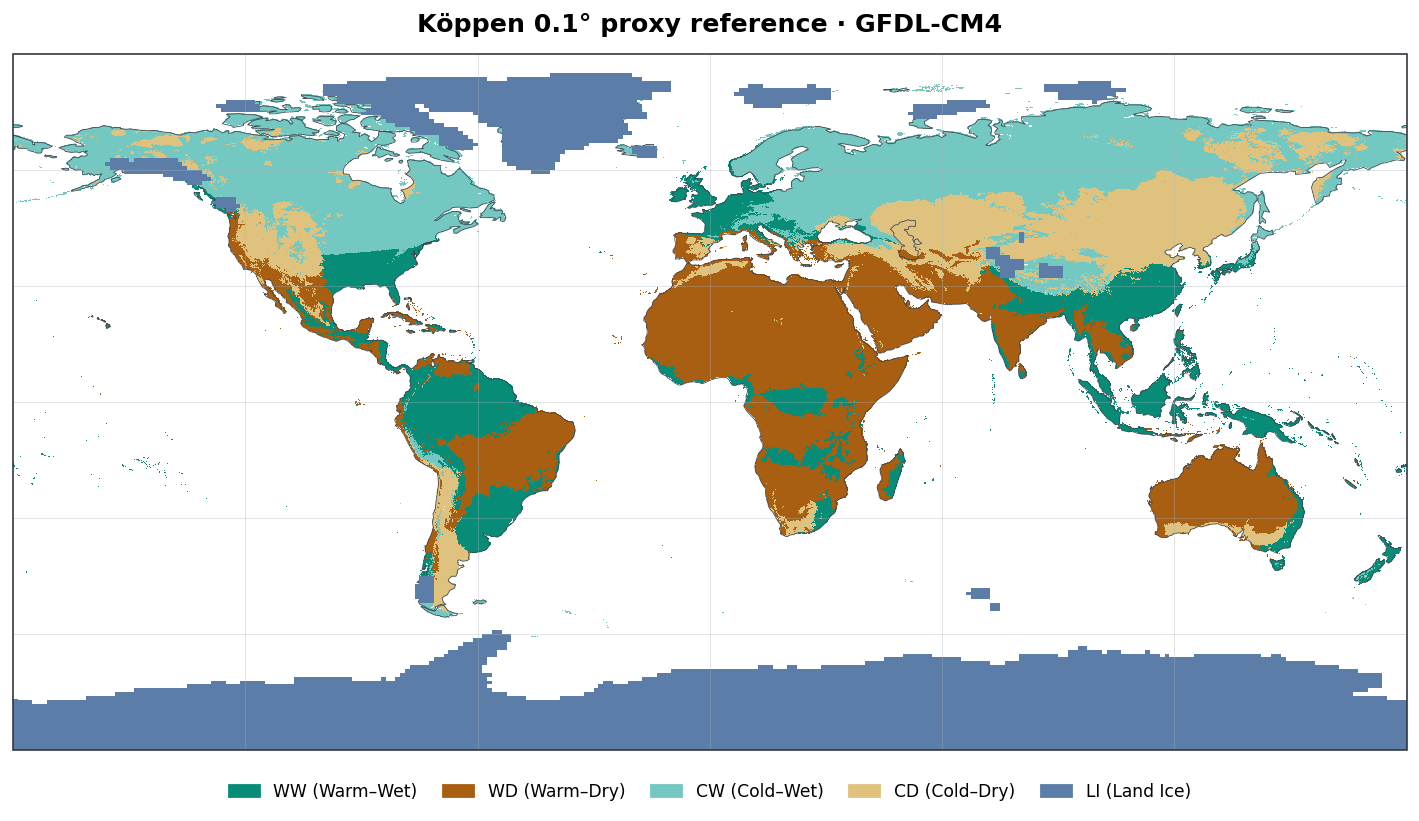

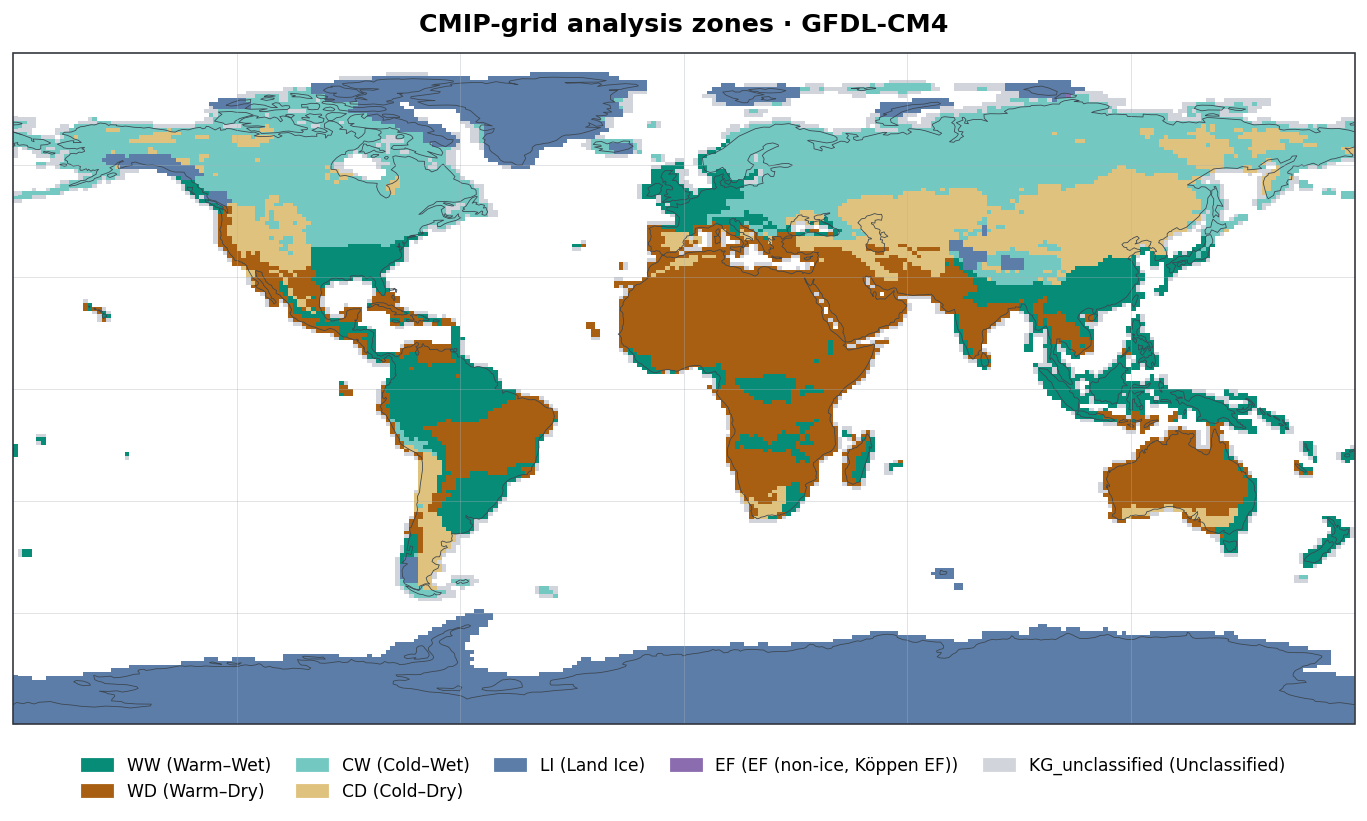

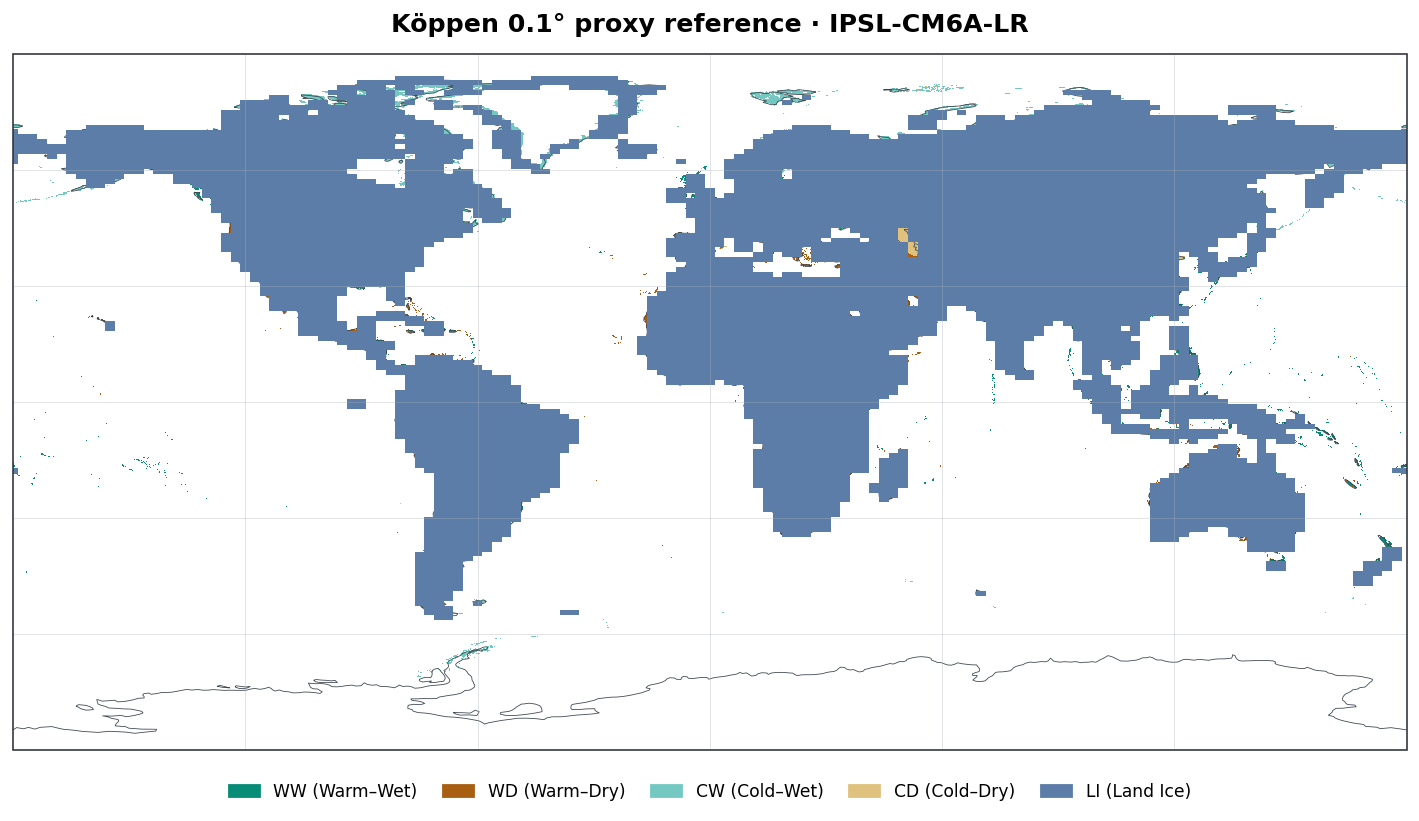

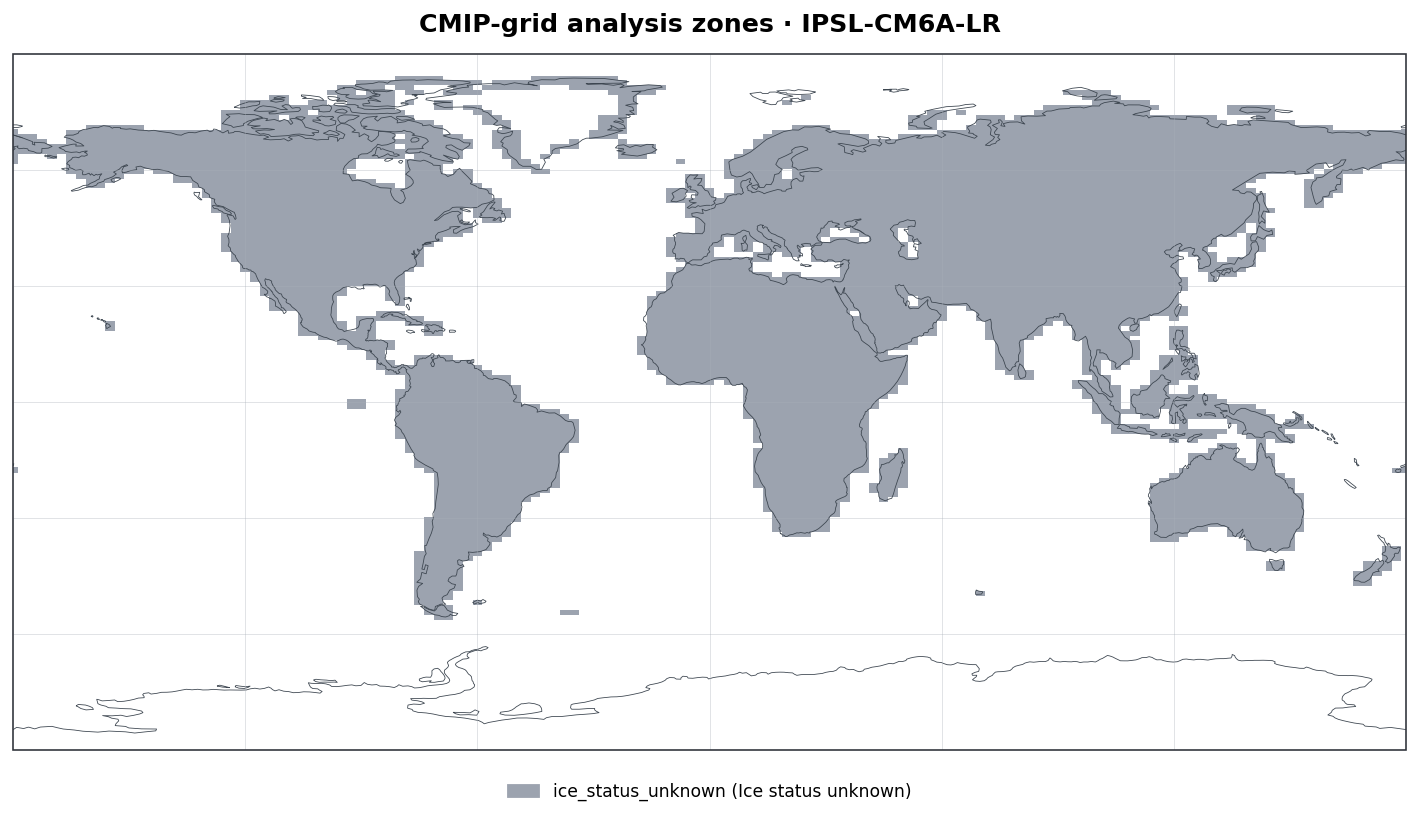

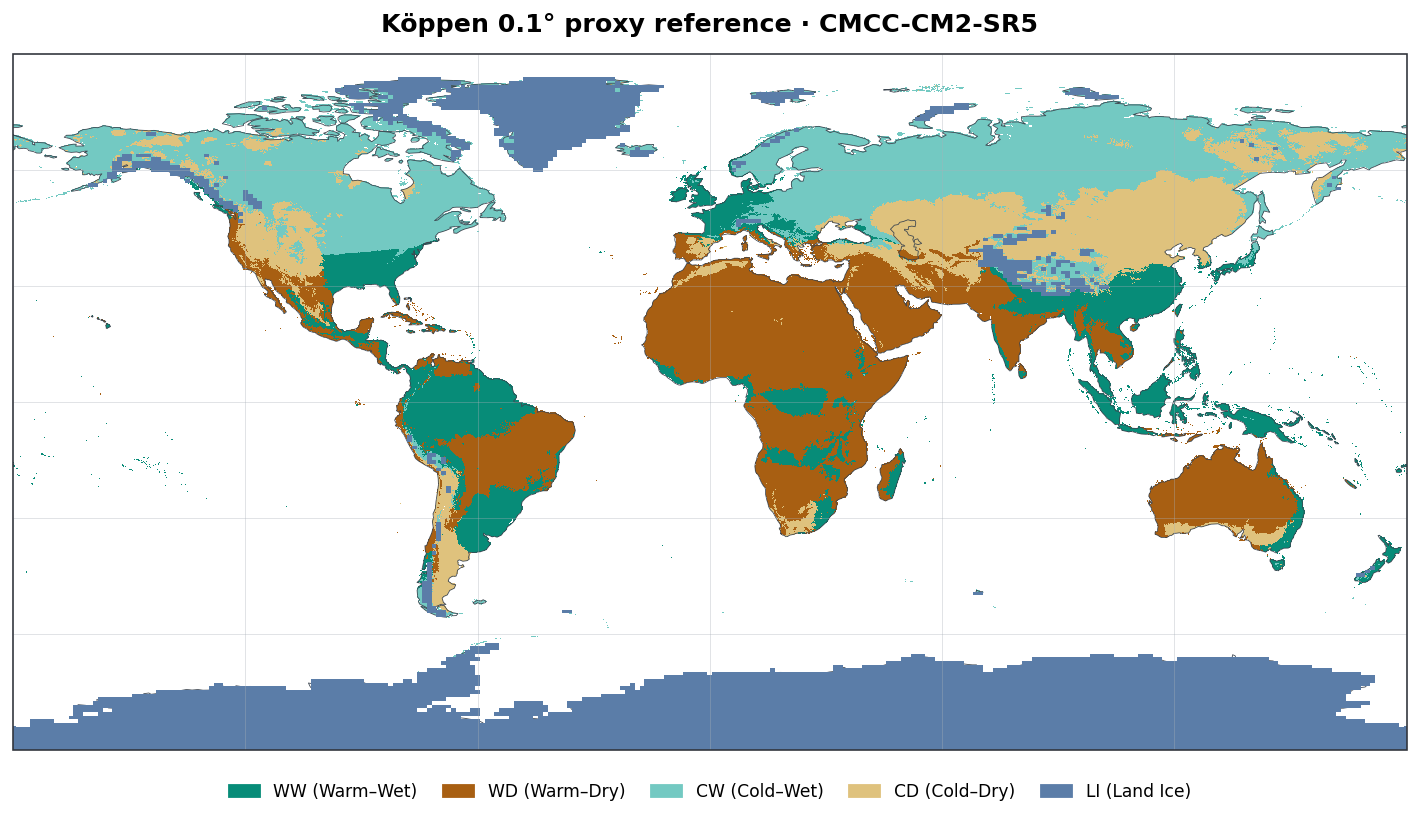

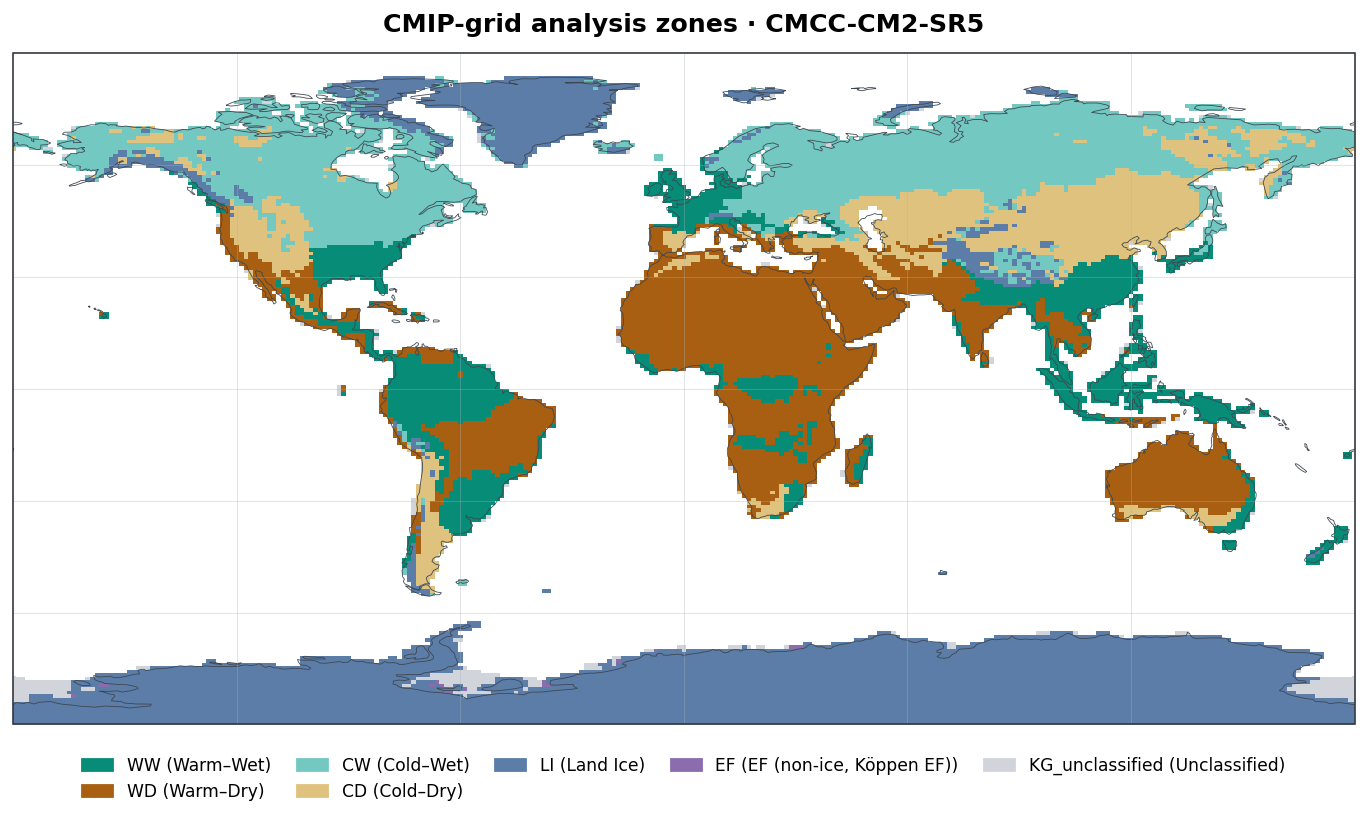

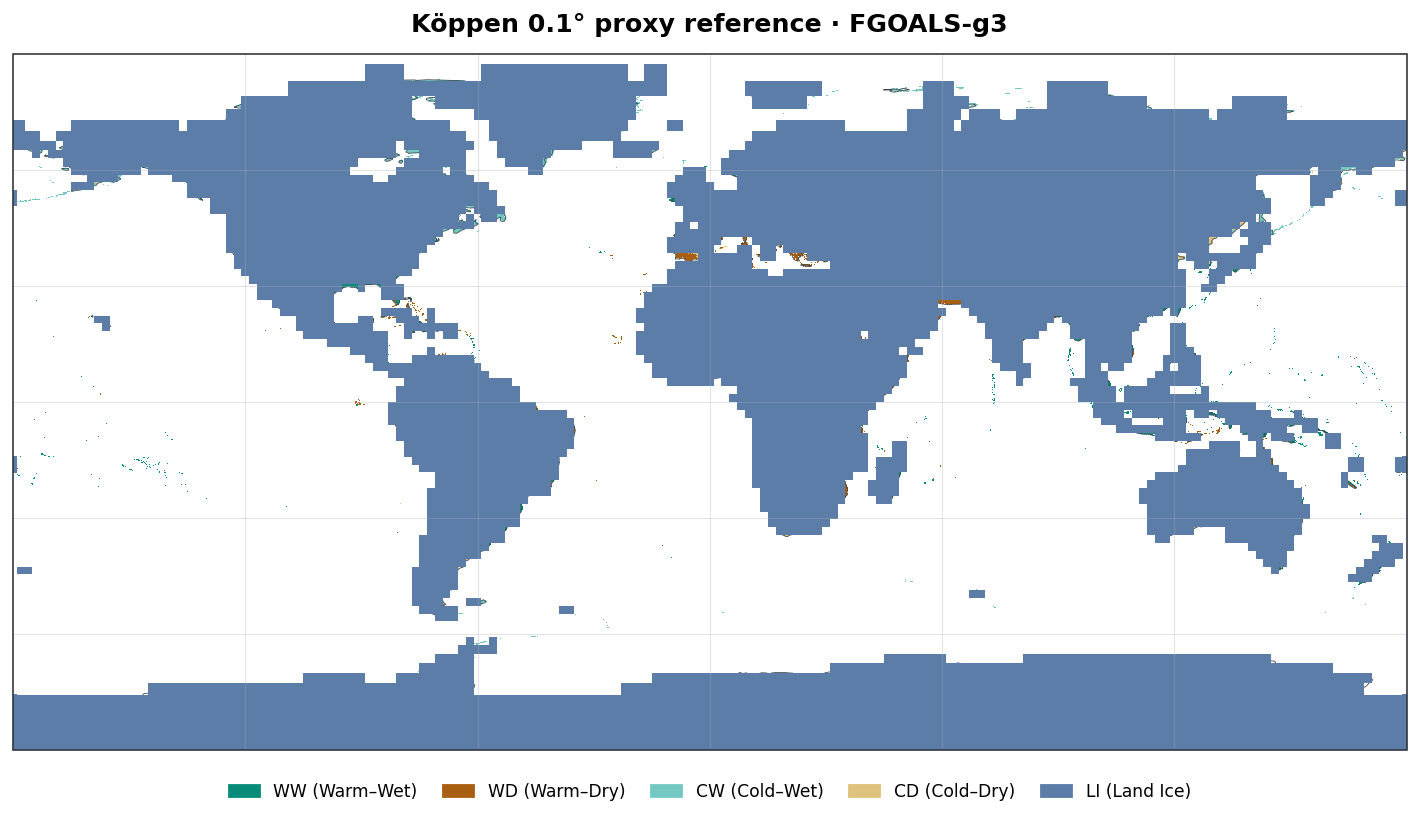

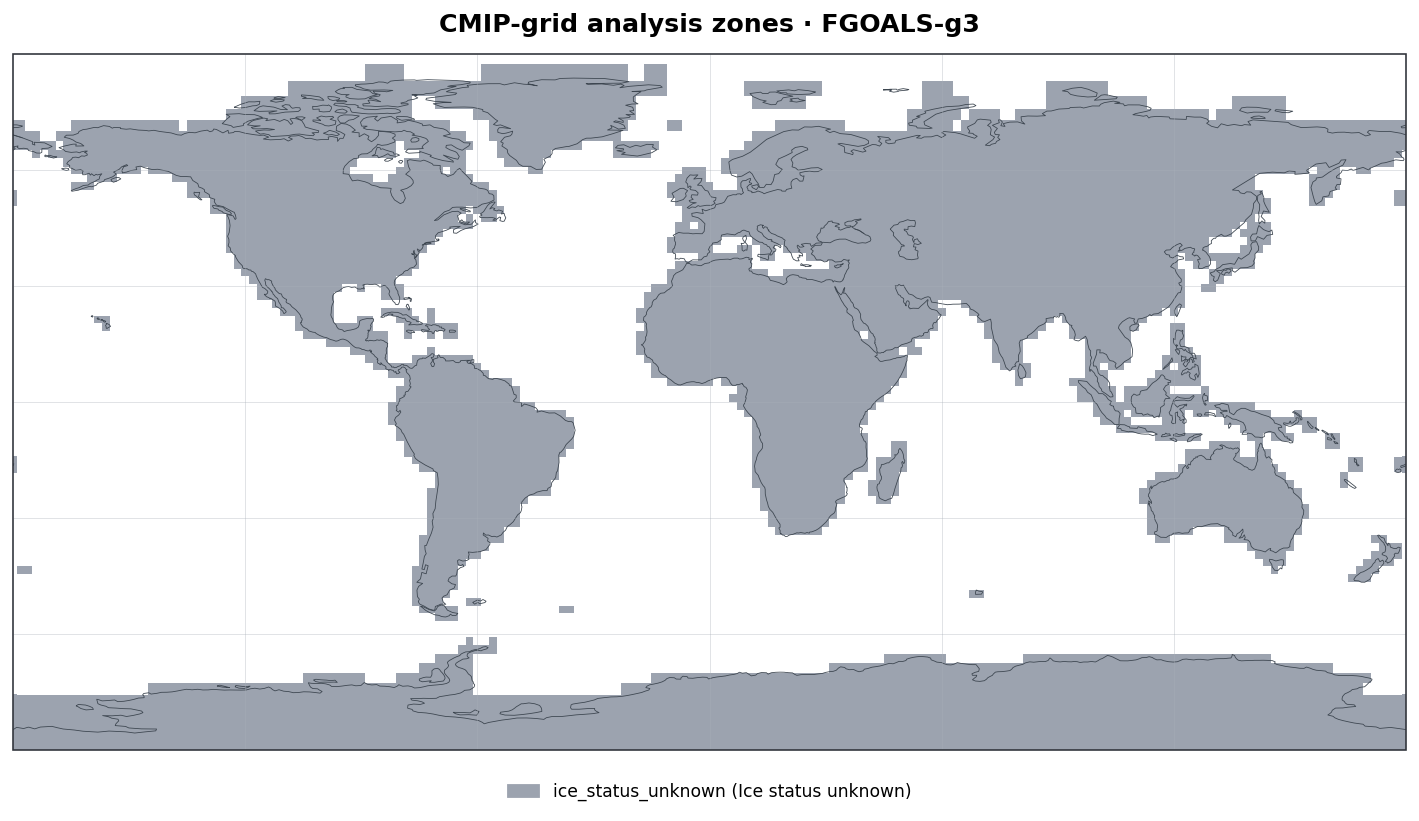

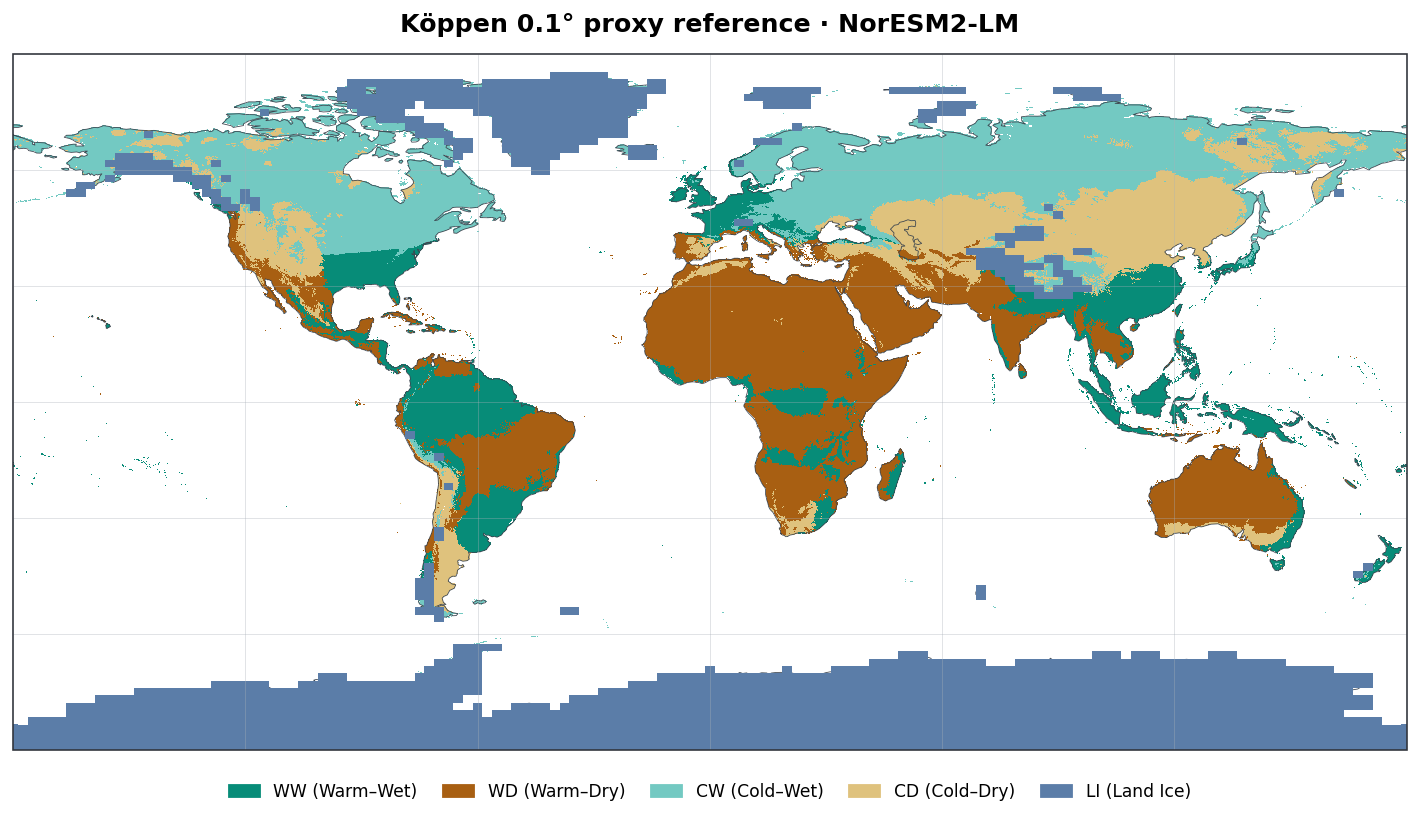

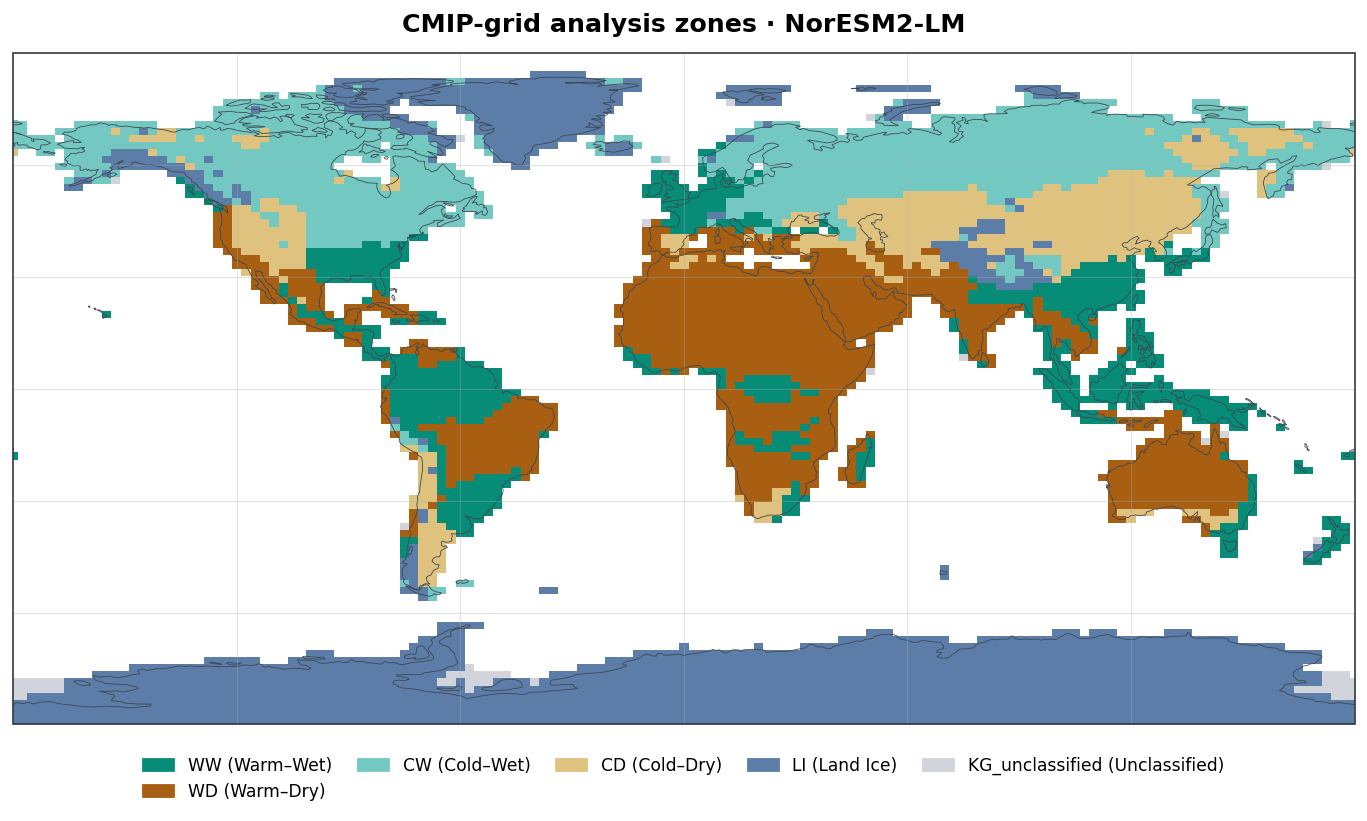

In [26]:
def style_map(ax):
    ax.set_global()
    ax.coastlines(resolution='110m', color='#3D4650', linewidth=0.45)
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
    ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=False,
        xlocs=np.arange(-120, 181, 60), ylocs=np.arange(-60, 91, 30),
        color='#AAB1B9', linewidth=0.35, alpha=0.55,
    )
    ax.spines['geo'].set_edgecolor('#30343B')
    ax.spines['geo'].set_linewidth(0.9)


SURFACE_CLASS_NAMES = {0: 'ocean', 1: 'non_ice_land', 2: 'land_ice', 3: 'land_ice_unknown'}

for res in ZONE_RESULTS:
    output_dir = res['land_dir'] / 'zones'
    output_dir.mkdir(parents=True, exist_ok=True)
    nc = res['land_clim_nc']
    cmip_lat = res['cmip_lat']
    cmip_lon = res['cmip_lon']
    agg = res['agg']

    # ── Map 1: 0.1° Köppen proxy reference ──
    zone_cmap_4 = ListedColormap([ZONE_COLORS[z] for z in ZONE_ORDER])
    zone_cmap_4.set_bad((1, 1, 1, 0))
    zone_norm_4 = BoundaryNorm(np.arange(0.5, 5.5, 1), zone_cmap_4.N)

    high_res_zone = np.zeros_like(kg_classes, dtype='float32')
    for koppen_code, zone_name in KOPPEN_TO_ZONE.items():
        high_res_zone[kg_classes == koppen_code] = ZONE_TO_CODE[zone_name]
    high_res_zone = np.ma.masked_where(high_res_zone == 0, high_res_zone)

    surface_class_grid = nc['surface_class_code'].values
    ice_mask_grid = (surface_class_grid == 2) | (surface_class_grid == 3)
    ice_overlay = np.ma.masked_where(
        ~ice_mask_grid, np.ones_like(surface_class_grid, dtype='float32'))

    projection = ccrs.PlateCarree()
    fig = plt.figure(figsize=(12.6, 6.2), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=projection)
    ax.imshow(
        high_res_zone, origin='upper',
        extent=[kg_lon.min() - 0.05, kg_lon.max() + 0.05,
                kg_lat.min() - 0.05, kg_lat.max() + 0.05],
        transform=ccrs.PlateCarree(), cmap=zone_cmap_4, norm=zone_norm_4,
        interpolation='nearest', rasterized=True, zorder=1,
    )
    ice_cmap = ListedColormap([ZONE_COLORS['LI']])
    ax.pcolormesh(
        nc['lon'], nc['lat'], ice_overlay,
        transform=ccrs.PlateCarree(), shading='auto',
        cmap=ice_cmap, vmin=0.5, vmax=1.5, rasterized=True, zorder=2,
    )
    style_map(ax)
    ax.set_title(
        f"Köppen 0.1° proxy reference · {res['model']}",
        pad=12, fontsize=14, fontweight='semibold',
    )
    legend_handles = [
        mpatches.Patch(color=ZONE_COLORS[z], label=f'{z} ({ZONE_LABELS[z]})')
        for z in ['WW', 'WD', 'CW', 'CD', 'LI']
    ]
    ax.legend(
        handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.025),
        ncol=5, frameon=False, fontsize=9.5, handlelength=1.8, columnspacing=1.5,
    )
    if WRITE_OUTPUTS:
        fig.savefig(output_dir / 'zone_map_koppen_reference.png', bbox_inches='tight')
    plt.show()

    # ── Map 2: CMIP-grid analysis_zone ──
    land_mask = nc['land_cell'].values.astype(bool)
    az_grid = np.zeros((len(cmip_lat), len(cmip_lon)), dtype='int8')
    for i in range(len(cmip_lat)):
        for j in range(len(cmip_lon)):
            if not land_mask[i, j]:
                continue
            sc_code = int(surface_class_grid[i, j])
            sc_str = SURFACE_CLASS_NAMES.get(sc_code, 'land_ice_unknown')
            dk = int(agg['dominant_koppen_code'][i, j])
            zidx = int(agg['dominant_zone_idx'][i, j])
            proxy = CODE_TO_ZONE.get(zidx)
            az = _assign_analysis_zone(sc_str, dk, proxy)
            az_grid[i, j] = ANALYSIS_ZONE_CODE_MAP.get(az, 8)

    present_zones = [z for z in ANALYSIS_ZONE_ALL if (az_grid == ANALYSIS_ZONE_CODE_MAP[z]).any()]
    n_present = len(present_zones)
    az_colors = [ZONE_COLORS[z] for z in present_zones]
    az_codes = [ANALYSIS_ZONE_CODE_MAP[z] for z in present_zones]
    az_cmap = ListedColormap(az_colors)
    az_cmap.set_bad((1, 1, 1, 0))
    az_boundaries = [c - 0.5 for c in az_codes] + [az_codes[-1] + 0.5]
    az_norm = BoundaryNorm(az_boundaries, az_cmap.N)
    az_display = np.ma.masked_where(az_grid == 0, az_grid.astype('float32'))

    fig2 = plt.figure(figsize=(12.6, 6.2), constrained_layout=True)
    ax2 = fig2.add_subplot(1, 1, 1, projection=projection)
    ax2.pcolormesh(
        nc['lon'], nc['lat'], az_display,
        transform=ccrs.PlateCarree(), shading='auto',
        cmap=az_cmap, norm=az_norm, rasterized=True,
    )
    style_map(ax2)
    ax2.set_title(
        f"CMIP-grid analysis zones · {res['model']}",
        pad=12, fontsize=14, fontweight='semibold',
    )
    legend2 = [
        mpatches.Patch(color=ZONE_COLORS[z], label=f'{z} ({ZONE_LABELS[z]})')
        for z in present_zones
    ]
    ax2.legend(
        handles=legend2, loc='upper center', bbox_to_anchor=(0.5, -0.025),
        ncol=min(n_present, 5), frameon=False, fontsize=9.5,
        handlelength=1.8, columnspacing=1.5,
    )
    if WRITE_OUTPUTS:
        fig2.savefig(output_dir / 'zone_map_cmip_grid.png', bbox_inches='tight')
    plt.show()

## 7. Purity diagnostic / 纯度诊断

Area-weighted purity distribution for the four non-ice zones. This checks how cleanly the coarse CMIP grid cells separate into proxy zones. Land-ice cells are excluded from this diagnostic because they do not participate in the four-zone split.

**中文说明：** 仅对非冰四区展示面积加权的纯度分布，检查粗分辨率CMIP格点的分区一致性。陆地冰不参与此诊断。

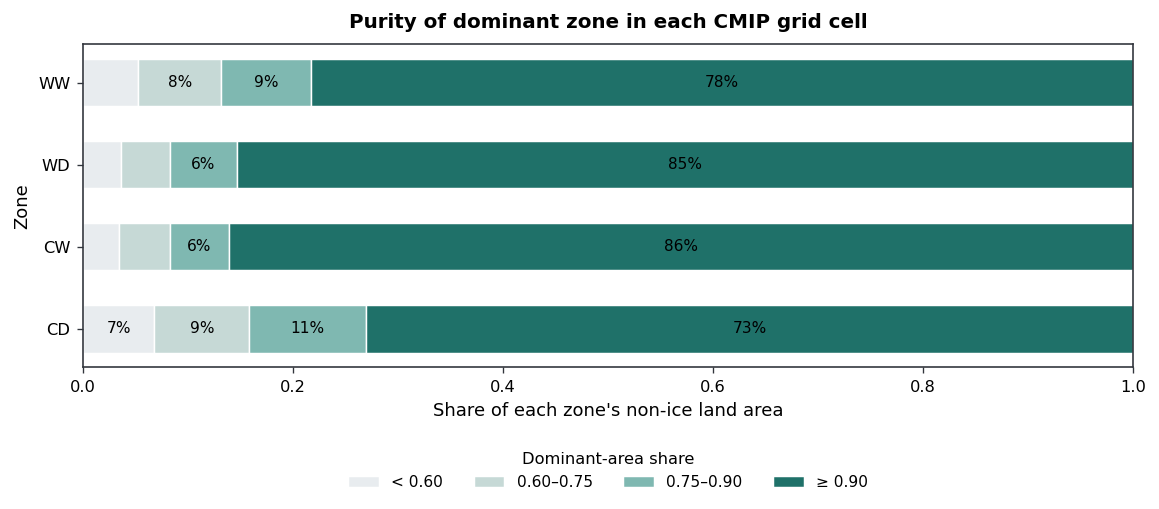

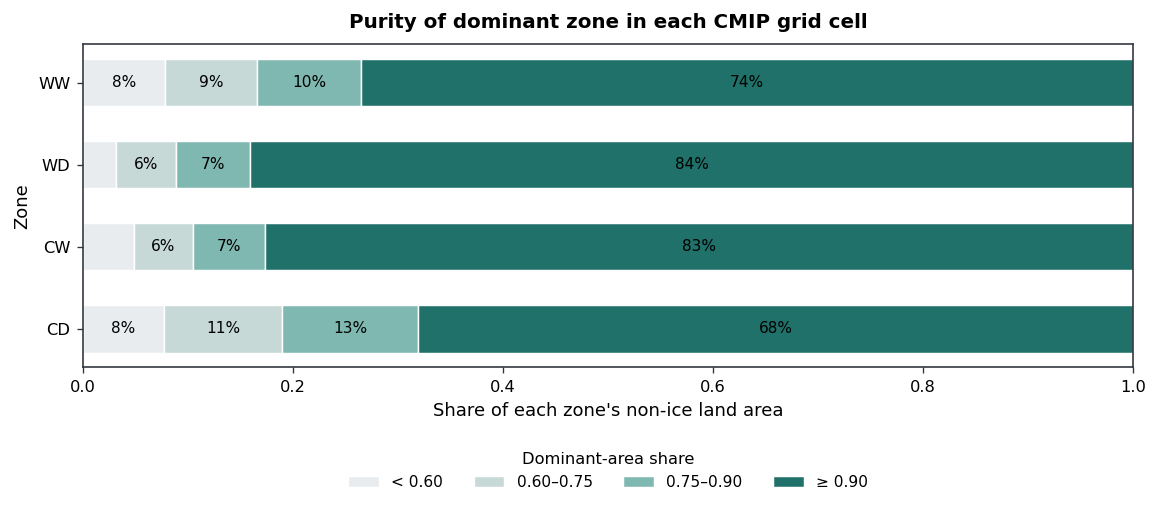

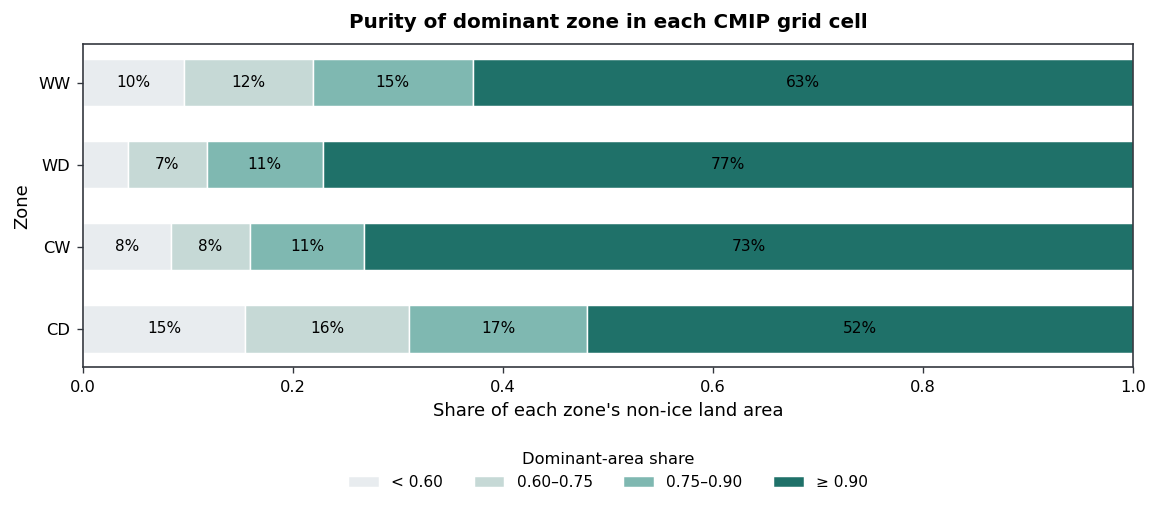

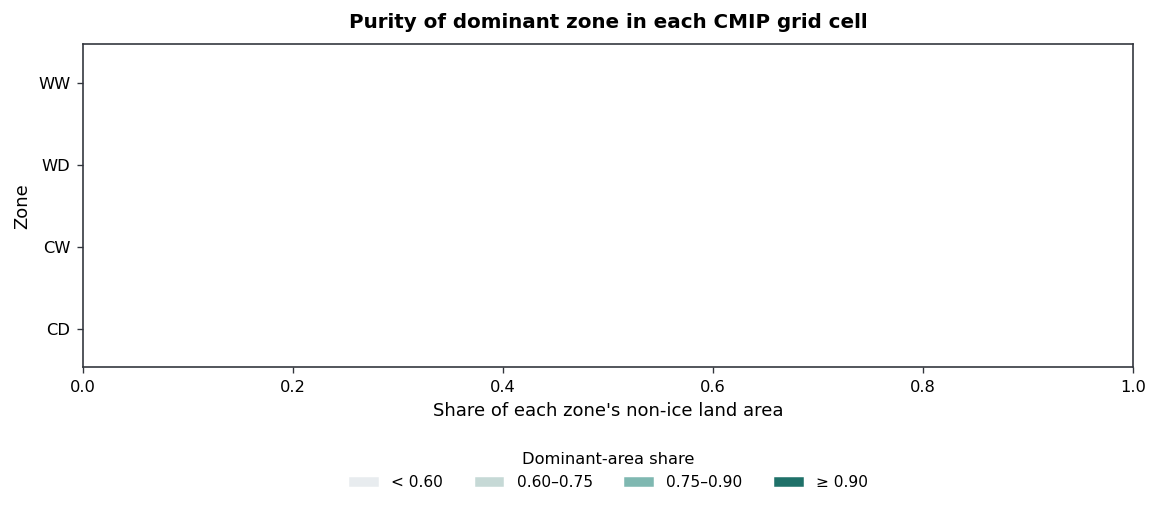

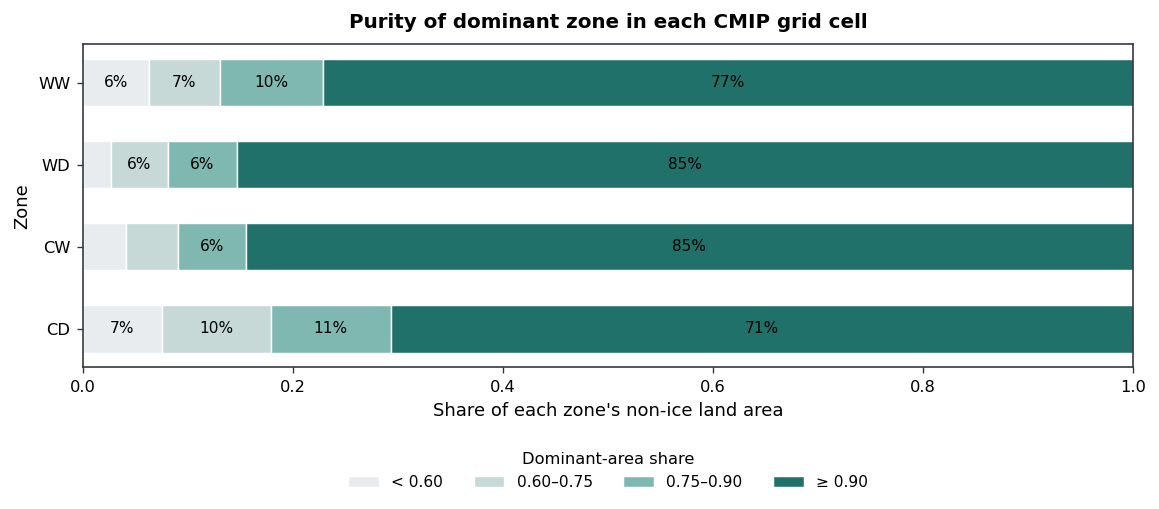

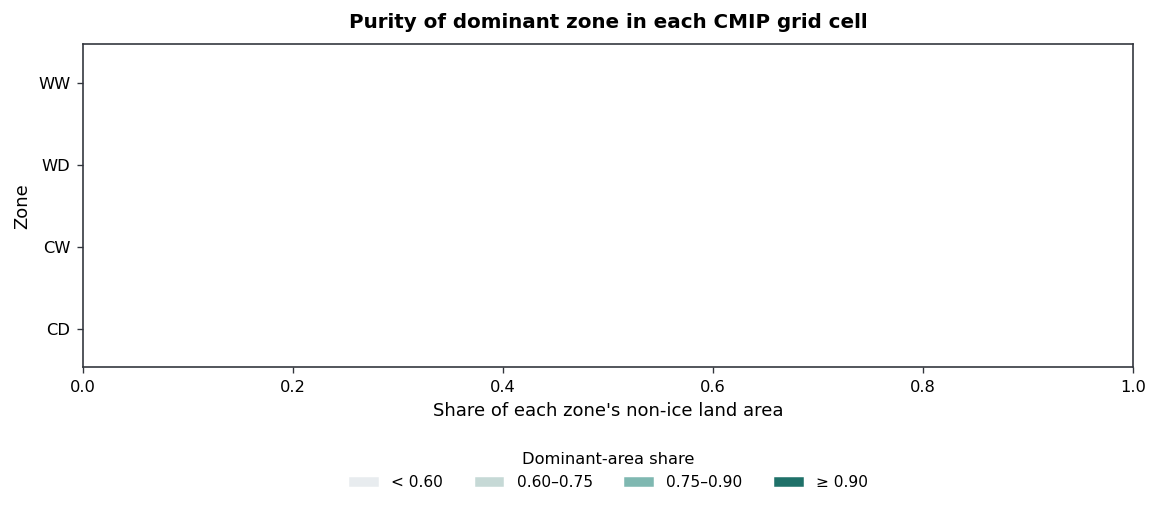

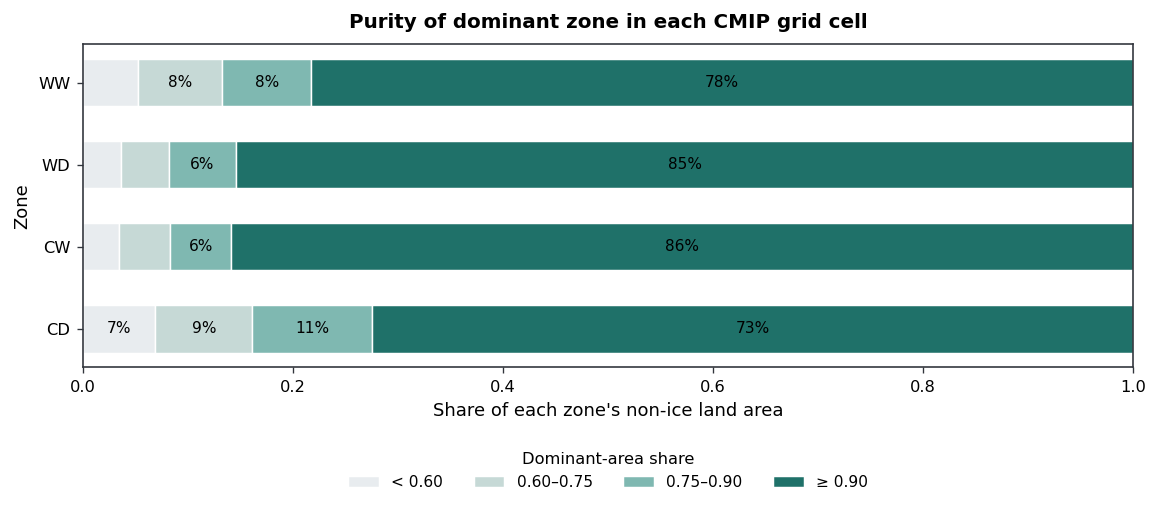

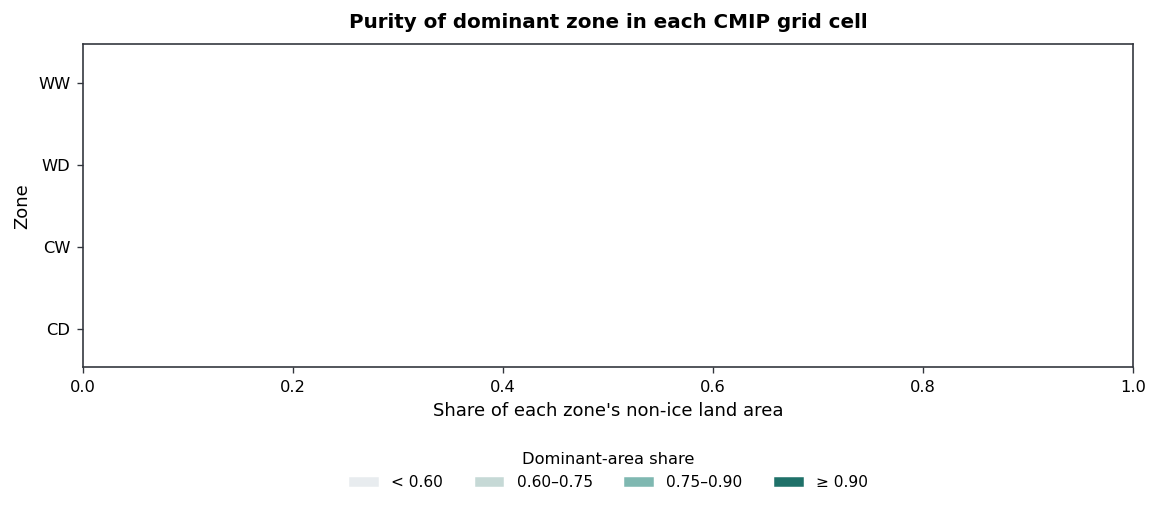

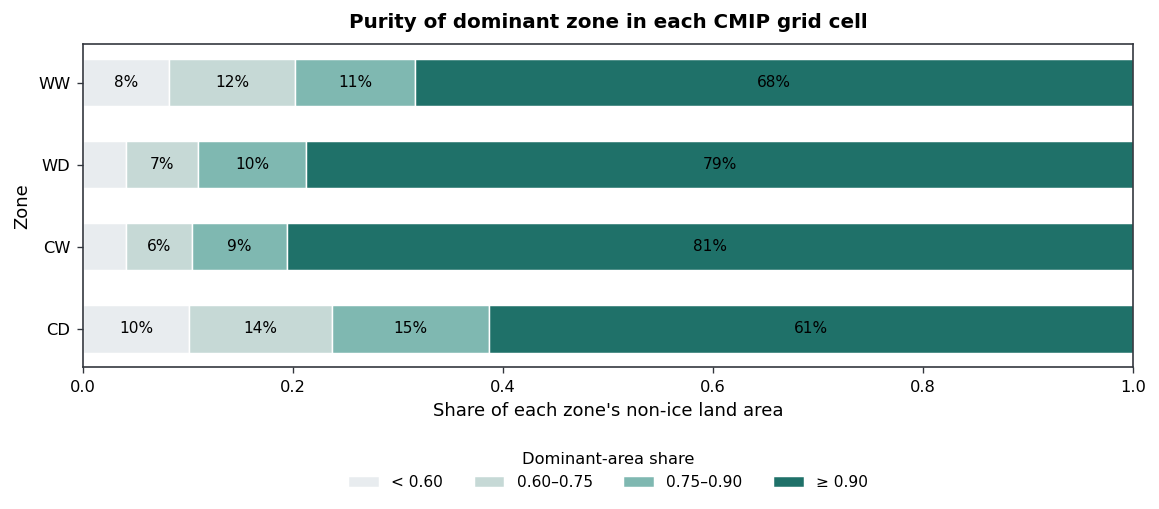

In [27]:
def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#30343B')
        spine.set_linewidth(0.9)
    ax.tick_params(direction='out', length=3.5, width=0.75, color='#30343B')
    ax.grid(True, color='#D3D3D3', linewidth=0.8, alpha=0.80, zorder=0)


for res in ZONE_RESULTS:
    t = res['zoned_table']
    non_ice = t.loc[t['analysis_zone'].isin(ZONE_ORDER)].copy()
    output_dir = res['land_dir'] / 'zones'
    output_dir.mkdir(parents=True, exist_ok=True)

    purity_edges = np.array([0.0, 0.60, 0.75, 0.90, 1.000001])
    purity_labels = ['< 0.60', '0.60–0.75', '0.75–0.90', '≥ 0.90']
    purity_colors = ['#E8ECEF', '#C6D9D6', '#7FB8B1', '#1F7169']
    purity_shares = []
    for zone_name in ZONE_ORDER:
        group = non_ice.loc[non_ice['analysis_zone'] == zone_name]
        weights = group['land_area'].to_numpy(float)
        values = group['zone_purity'].to_numpy(float)
        shares = []
        for lo, hi in zip(purity_edges[:-1], purity_edges[1:]):
            mask = (values >= lo) & (values < hi)
            shares.append(float(weights[mask].sum() / weights.sum()) if weights.sum() > 0 else 0)
        purity_shares.append(shares)
    purity_shares = np.asarray(purity_shares)

    fig, ax = plt.subplots(figsize=(8.8, 3.8), constrained_layout=True)
    left = np.zeros(len(ZONE_ORDER))
    for bin_i, (label, color) in enumerate(zip(purity_labels, purity_colors)):
        widths = purity_shares[:, bin_i]
        bars = ax.barh(
            ZONE_ORDER, widths, left=left, height=0.58,
            color=color, edgecolor='white', linewidth=0.8, label=label,
        )
        for row_i, (bar, w) in enumerate(zip(bars, widths)):
            if w >= 0.055:
                ax.text(left[row_i] + w / 2, bar.get_y() + bar.get_height() / 2,
                        f'{100 * w:.0f}%', ha='center', va='center', fontsize=8.5)
        left += widths
    ax.set_xlim(0, 1)
    ax.set_xlabel('Share of each zone\'s non-ice land area')
    ax.set_ylabel('Zone')
    ax.set_title('Purity of dominant zone in each CMIP grid cell', pad=9)
    ax.legend(title='Dominant-area share', frameon=False, ncol=4,
              loc='upper center', bbox_to_anchor=(0.5, -0.22),
              fontsize=8.5, title_fontsize=9)
    style_axes(ax)
    ax.grid(False)
    ax.invert_yaxis()
    if WRITE_OUTPUTS:
        fig.savefig(output_dir / 'zone_purity_distribution.png', bbox_inches='tight')
    plt.show()

## 8. Purity sensitivity check / 纯度敏感性检查

Recalculate key statistics using only core cells (purity >= 0.60) vs all assigned cells. If results differ substantially, the coarse-grid zone assignment needs more careful treatment.

**中文说明：** 只用纯度>=0.60的核心格点重新计算主要统计量，与全部格点结果对比。差异大则说明粗网格分类需要更仔细处理。

In [28]:
def weighted_quantile(values, weights, quantile=0.5):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if valid.sum() == 0:
        return np.nan
    order = np.argsort(values[valid])
    sv = values[valid][order]
    sw = weights[valid][order]
    cum = np.cumsum(sw)
    return float(sv[np.searchsorted(cum, quantile * cum[-1])])


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if valid.sum() == 0:
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


for res in ZONE_RESULTS:
    t = res['zoned_table']
    non_ice = t.loc[t['analysis_zone'].isin(ZONE_ORDER)]
    rows = []
    for zone_name in ZONE_ORDER:
        for sample, mask in [
            ('all_assigned', non_ice['analysis_zone'] == zone_name),
            ('core_purity_ge_0p60',
             (non_ice['analysis_zone'] == zone_name) & non_ice['core_zone_cell']),
        ]:
            g = non_ice.loc[mask]
            w = g['land_area']
            rows.append({
                'zone': zone_name, 'sample': sample, 'grid_cells': len(g),
                'P_median': weighted_quantile(g['P'], w),
                'ET_median': weighted_quantile(g['ET'], w),
                'R_median': weighted_quantile(g['R'], w),
                'ET_over_P_median': weighted_quantile(g['ET_over_P'], w),
                'R_over_P_median': weighted_quantile(g['R_over_P'], w),
            })
    sens = pd.DataFrame(rows)
    display(sens.set_index(['zone', 'sample']).round(3))

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned               2410  1561.020    958.369   640.715   
     core_purity_ge_0p60        2297  1567.663    978.110   650.108   
WD   all_assigned               4177   547.347    505.317    67.638   
     core_purity_ge_0p60        4020   535.092    497.580    64.055   
CW   all_assigned               4642   566.426    333.950   243.872   
     core_purity_ge_0p60        4521   565.747    333.560   245.213   
CD   all_assigned               2325   437.842    344.273    72.694   
     core_purity_ge_0p60        2161   430.291    337.648    67.647   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                    0.613            0.400  
     core_purity_ge_0p60             0.612            0.402  
WD   all_assigned                    0.921            0.144  
     core_purity_ge_0p60             0.926            0.137  
CW   all_assigned                    0.566            0.446  
     core_purity_ge_0p60             0.562            0.450  
CD   all_assigned                    0.828            0.195  
     core_purity_ge_0p60             0.832            0.193

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned               1716  1451.514    987.223   382.140   
     core_purity_ge_0p60        1607  1460.248   1002.574   382.661   
WD   all_assigned               2670   405.595    427.633    28.127   
     core_purity_ge_0p60        2582   389.843    411.169    26.541   
CW   all_assigned               2821   616.570    386.446   202.463   
     core_purity_ge_0p60        2720   608.105    384.731   196.197   
CD   all_assigned               1427   465.313    359.720    73.053   
     core_purity_ge_0p60        1315   442.155    355.337    65.438   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                    0.764            0.264  
     core_purity_ge_0p60             0.763            0.264  
WD   all_assigned                    0.978            0.063  
     core_purity_ge_0p60             0.980            0.061  
CW   all_assigned                    0.678            0.340  
     core_purity_ge_0p60             0.683            0.334  
CD   all_assigned                    0.879            0.162  
     core_purity_ge_0p60             0.889            0.154

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned                467  1516.078   1069.950   424.696   
     core_purity_ge_0p60         425  1524.100   1083.495   429.073   
WD   all_assigned                710   522.272    625.982     9.650   
     core_purity_ge_0p60         671   513.579    609.744     8.571   
CW   all_assigned                806   614.000    364.938   243.078   
     core_purity_ge_0p60         758   609.391    355.394   241.721   
CD   all_assigned                373   418.030    364.230    21.742   
     core_purity_ge_0p60         316   413.818    360.574    19.514   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                    0.741            0.274  
     core_purity_ge_0p60             0.741            0.272  
WD   all_assigned                    1.001            0.015  
     core_purity_ge_0p60             1.002            0.014  
CW   all_assigned                    0.605            0.426  
     core_purity_ge_0p60             0.599            0.427  
CD   all_assigned                    0.978            0.048  
     core_purity_ge_0p60             0.981            0.041

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
WD   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
CW   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
CD   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
WD   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
CW   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
CD   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned               2653  1529.542   1100.733   290.191   
     core_purity_ge_0p60        2519  1532.637   1108.203   291.159   
WD   all_assigned               4162   575.522    609.347    13.385   
     core_purity_ge_0p60        4046   555.702    588.901    12.014   
CW   all_assigned               4714   600.325    392.560   147.638   
     core_purity_ge_0p60        4582   598.733    388.044   147.583   
CD   all_assigned               2272   431.429    359.885    43.686   
     core_purity_ge_0p60        2101   424.435    354.780    41.571   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                    0.740            0.178  
     core_purity_ge_0p60             0.740            0.178  
WD   all_assigned                    0.979            0.034  
     core_purity_ge_0p60             0.981            0.032  
CW   all_assigned                    0.609            0.246  
     core_purity_ge_0p60             0.609            0.245  
CD   all_assigned                    0.894            0.111  
     core_purity_ge_0p60             0.896            0.109

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
WD   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
CW   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
CD   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
WD   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
CW   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
CD   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned               2419  1502.602   1012.269   722.391   
     core_purity_ge_0p60        2306  1507.556   1022.813   722.352   
WD   all_assigned               4114   722.082    667.460    58.113   
     core_purity_ge_0p60        3957   702.638    659.597    52.399   
CW   all_assigned               4507   614.460    396.284   271.231   
     core_purity_ge_0p60        4385   612.750    394.019   272.765   
CD   all_assigned               2289   508.320    411.772    52.598   
     core_purity_ge_0p60        2127   500.796    408.017    48.075   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                    0.699            0.504  
     core_purity_ge_0p60             0.699            0.503  
WD   all_assigned                    0.948            0.092  
     core_purity_ge_0p60             0.952            0.088  
CW   all_assigned                    0.626            0.490  
     core_purity_ge_0p60             0.621            0.492  
CD   all_assigned                    0.929            0.098  
     core_purity_ge_0p60             0.934            0.093

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
WD   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
CW   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   
CD   all_assigned                  0       NaN        NaN       NaN   
     core_purity_ge_0p60           0       NaN        NaN       NaN   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
WD   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
CW   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN  
CD   all_assigned                      NaN              NaN  
     core_purity_ge_0p60               NaN              NaN

grid_cells  P_median  ET_median  R_median  \
zone sample                                                           
WW   all_assigned                723  1518.527   1073.843   534.753   
     core_purity_ge_0p60         672  1564.021   1095.075   543.767   
WD   all_assigned               1150   569.792    528.938    72.558   
     core_purity_ge_0p60        1096   542.516    517.352    65.076   
CW   all_assigned               1229   590.892    323.211   276.674   
     core_purity_ge_0p60        1187   589.261    317.170   276.674   
CD   all_assigned                592   420.753    319.953    76.145   
     core_purity_ge_0p60         535   416.213    316.156    74.648   

                          ET_over_P_median  R_over_P_median  
zone sample                                                  
WW   all_assigned                    0.669            0.359  
     core_purity_ge_0p60             0.663            0.362  
WD   all_assigned                    0.930            0.141  
     core_purity_ge_0p60             0.937            0.134  
CW   all_assigned                    0.528            0.480  
     core_purity_ge_0p60             0.522            0.483  
CD   all_assigned                    0.838            0.195  
     core_purity_ge_0p60             0.840            0.193

## 9. Save outputs / 保存输出

Products per run:
- `zone_climatology_{period}.parquet` — full land table with all zone fields added
- `zone_grid_year_{period}.parquet` — annual table with `analysis_zone` joined via `grid_id`
- `zone_gridded_{period}.nc` — gridded zone codes for spatial plotting
- `zone_summary_{period}.csv` — per-zone statistics
- Figures in `zones/`

**中文说明：** 每个run输出：含全部分区字段的气候态Parquet、通过grid_id加入analysis_zone的年度Parquet、空间绘图用的NetCDF、分区统计CSV、以及图片。

In [29]:
for res in ZONE_RESULTS:
    t = res['zoned_table']
    output_dir = res['land_dir'] / 'zones'
    period = f'{START_YEAR}_{END_YEAR}'

    if not WRITE_OUTPUTS:
        print(f"WRITE_OUTPUTS=False, skipping save for {res['model']}")
        continue

    output_dir.mkdir(parents=True, exist_ok=True)

    # --- climatology table with zone fields ---
    clim_path = output_dir / f'zone_climatology_{period}.parquet'
    t.to_parquet(clim_path, index=False, compression='zstd')

    # --- annual table with analysis_zone joined ---
    gy = pd.read_parquet(res['grid_year_table_path'])
    zone_lookup_cols = [
        'grid_id', 'analysis_zone', 'dominant_koppen_code',
        'dominant_koppen_class', 'koppen_major',
        'zone_purity', 'kg_grouped_coverage', 'kg_mean_confidence',
        'dominant_koppen_fraction',
        'fraction_WW', 'fraction_WD', 'fraction_CW', 'fraction_CD', 'fraction_EF',
        'core_zone_cell',
    ]
    zone_lookup = t[zone_lookup_cols].copy()
    n_gy_before = len(gy)
    gy_zoned = gy.merge(zone_lookup, on='grid_id', how='left', validate='many_to_one')
    assert len(gy_zoned) == n_gy_before, 'Merge changed row count'
    assert gy_zoned['analysis_zone'].notna().all(), 'Some grid-year rows missing analysis_zone'
    gy_path = output_dir / f'zone_grid_year_{period}.parquet'
    gy_zoned.to_parquet(gy_path, index=False, compression='zstd')

    # --- gridded NetCDF (uses same _assign_analysis_zone function) ---
    nc = res['land_clim_nc']
    cmip_lat = res['cmip_lat']
    cmip_lon = res['cmip_lon']
    agg = res['agg']
    land_mask = nc['land_cell'].values.astype(bool)
    surface_class_grid = nc['surface_class_code'].values

    az_grid = np.zeros((len(cmip_lat), len(cmip_lon)), dtype='int8')
    for i in range(len(cmip_lat)):
        for j in range(len(cmip_lon)):
            if not land_mask[i, j]:
                continue
            sc_code = int(surface_class_grid[i, j])
            sc_str = SURFACE_CLASS_NAMES.get(sc_code, 'land_ice_unknown')
            dk = int(agg['dominant_koppen_code'][i, j])
            zidx = int(agg['dominant_zone_idx'][i, j])
            proxy = CODE_TO_ZONE.get(zidx)
            az = _assign_analysis_zone(sc_str, dk, proxy)
            az_grid[i, j] = ANALYSIS_ZONE_CODE_MAP.get(az, 8)

    zone_ds = xr.Dataset(
        {
            'analysis_zone_code': (['lat', 'lon'], az_grid),
            'zone_purity': (['lat', 'lon'],
                            np.where(land_mask, agg['zone_purity'], np.nan).astype('float32')),
            'kg_grouped_coverage': (['lat', 'lon'],
                                    np.where(land_mask, agg['kg_grouped_coverage'], np.nan).astype('float32')),
            'kg_mean_confidence': (['lat', 'lon'],
                                   np.where(land_mask, agg['kg_mean_confidence'], np.nan).astype('float32')),
            'dominant_koppen_code': (['lat', 'lon'],
                                     np.where(land_mask, agg['dominant_koppen_code'], 0).astype('int16')),
            'dominant_koppen_fraction': (['lat', 'lon'],
                                         np.where(land_mask, agg['dominant_koppen_fraction'], np.nan).astype('float32')),
            'surface_class_code': nc['surface_class_code'],
            'land_cell': nc['land_cell'],
        },
        coords={'lat': cmip_lat, 'lon': cmip_lon},
    )
    for frac_name in ['fraction_WW', 'fraction_WD', 'fraction_CW', 'fraction_CD', 'fraction_EF']:
        zone_ds[frac_name] = (['lat', 'lon'],
                               np.where(land_mask, agg[frac_name], np.nan).astype('float32'))

    zone_ds['analysis_zone_code'].attrs = {
        'long_name': 'Koppen proxy zone',
        'flag_values': np.array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int8'),
        'flag_meanings': 'ocean WW WD CW CD LI EF ice_status_unknown KG_unclassified',
    }
    zone_ds.attrs = {
        'title': 'Koppen-based proxy zones on CMIP land grid',
        'source_id': res['model'],
        'experiment_id': res['experiment'],
        'member_id': res['member'],
        'grid_label': res['grid'],
        'analysis_period': f'{START_YEAR}-{END_YEAR}',
        'aggregation': 'cos(latitude)-weighted dominant group of 0.1-degree pixel centers',
        'processing_version': PROCESSING_VERSION,
    }
    nc_path = output_dir / f'zone_gridded_{period}.nc'
    encoding = {name: {'zlib': True, 'complevel': 4} for name in zone_ds.data_vars}
    zone_ds.to_netcdf(nc_path, encoding=encoding)

    # --- zone summary CSV ---
    non_ice = t.loc[t['analysis_zone'].isin(ZONE_ORDER)]
    total_non_ice_area = non_ice['land_area'].sum()
    summary_rows = []
    for zone_name in ZONE_ORDER:
        g = non_ice.loc[non_ice['analysis_zone'] == zone_name]
        w = g['land_area']
        summary_rows.append({
            'zone': zone_name,
            'grid_cells': len(g),
            'land_area_share': float(w.sum() / total_non_ice_area) if total_non_ice_area > 0 else 0,
            'core_cell_share': float(g['core_zone_cell'].mean()) if len(g) > 0 else np.nan,
            'median_zone_purity': weighted_quantile(g['zone_purity'], w),
            'P_median': weighted_quantile(g['P'], w),
            'ET_median': weighted_quantile(g['ET'], w),
            'R_median': weighted_quantile(g['R'], w),
            'ET_over_P_median': weighted_quantile(g['ET_over_P'], w),
            'R_over_P_median': weighted_quantile(g['R_over_P'], w),
        })
    li_cells = t.loc[t['analysis_zone'] == 'LI']
    summary_rows.append({
        'zone': 'LI',
        'grid_cells': len(li_cells),
        'land_area_share': np.nan,
        'core_cell_share': np.nan,
        'median_zone_purity': np.nan,
        'P_median': weighted_quantile(li_cells['P'], li_cells['land_area']),
        'ET_median': weighted_quantile(li_cells['ET'], li_cells['land_area']),
        'R_median': weighted_quantile(li_cells['R'], li_cells['land_area']),
        'ET_over_P_median': np.nan,
        'R_over_P_median': np.nan,
    })
    zone_summary_df = pd.DataFrame(summary_rows)
    summary_path = output_dir / f'zone_summary_{period}.csv'
    zone_summary_df.to_csv(summary_path, index=False)
    display(zone_summary_df.round(3))

    # --- manifest ---
    outputs = [clim_path, gy_path, nc_path, summary_path]
    manifest = pd.DataFrame([{
        'product': p.name,
        'size_MB': p.stat().st_size / 1e6,
        'path': str(p),
    } for p in outputs])
    display(manifest.round({'size_MB': 3}))

,zone,grid_cells,land_area_share,core_cell_share,median_zone_purity,P_median,ET_median,R_median,ET_over_P_median,R_over_P_median
0,WW,2410,0.199,0.953,1.0,1561.020,958.369,640.715,0.613,0.400
1,WD,4177,0.396,0.962,1.0,547.347,505.317,67.638,0.921,0.144
2,CW,4642,0.231,0.974,1.0,566.426,333.950,243.872,0.566,0.446
3,CD,2325,0.174,0.929,1.0,437.842,344.273,72.694,0.828,0.195
4,LI,7022,NaN,NaN,NaN,232.484,11.798,0.000,NaN,NaN


,product,size_MB,path
0,zone_climatology_1985_2014.parquet,4.215,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
1,zone_grid_year_1985_2014.parquet,90.143,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
2,zone_gridded_1985_2014.nc,0.269,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...
3,zone_summary_1985_2014.csv,0.001,/Volumes/mimi-T9/CMIP6/CESM2/historical/r1i1p1...


,zone,grid_cells,land_area_share,core_cell_share,median_zone_purity,P_median,ET_median,R_median,ET_over_P_median,R_over_P_median
0,WW,1716,0.203,0.936,1.0,1451.514,987.223,382.140,0.764,0.264
1,WD,2670,0.395,0.967,1.0,405.595,427.633,28.127,0.978,0.063
2,CW,2821,0.228,0.964,1.0,616.570,386.446,202.463,0.678,0.340
3,CD,1427,0.175,0.922,1.0,465.313,359.720,73.053,0.879,0.162
4,LI,4610,NaN,NaN,NaN,206.365,21.075,162.721,NaN,NaN


,product,size_MB,path
0,zone_climatology_1985_2014.parquet,2.633,/Volumes/mimi-T9/CMIP6/CNRM-CM6-1/historical/r...
1,zone_grid_year_1985_2014.parquet,55.127,/Volumes/mimi-T9/CMIP6/CNRM-CM6-1/historical/r...
2,zone_gridded_1985_2014.nc,0.211,/Volumes/mimi-T9/CMIP6/CNRM-CM6-1/historical/r...
3,zone_summary_1985_2014.csv,0.001,/Volumes/mimi-T9/CMIP6/CNRM-CM6-1/historical/r...


,zone,grid_cells,land_area_share,core_cell_share,median_zone_purity,P_median,ET_median,R_median,ET_over_P_median,R_over_P_median
0,WW,467,0.198,0.910,0.977,1516.078,1069.950,424.696,0.741,0.274
1,WD,710,0.385,0.945,1.000,522.272,625.982,9.650,1.001,0.015
2,CW,806,0.243,0.940,1.000,614.000,364.938,243.078,0.605,0.426
3,CD,373,0.174,0.847,0.912,418.030,364.230,21.742,0.978,0.048
4,LI,1095,NaN,NaN,NaN,145.716,17.585,122.923,NaN,NaN


...

,product,size_MB,path
0,zone_climatology_1985_2014.parquet,4.180,/Volumes/mimi-T9/CMIP6/CMCC-CM2-SR5/historical...
1,zone_grid_year_1985_2014.parquet,90.170,/Volumes/mimi-T9/CMIP6/CMCC-CM2-SR5/historical...
2,zone_gridded_1985_2014.nc,0.268,/Volumes/mimi-T9/CMIP6/CMCC-CM2-SR5/historical...
3,zone_summary_1985_2014.csv,0.001,/Volumes/mimi-T9/CMIP6/CMCC-CM2-SR5/historical...


,zone,grid_cells,land_area_share,core_cell_share,median_zone_purity,P_median,ET_median,R_median,ET_over_P_median,R_over_P_median
0,WW,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WD,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CW,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CD,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LI,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,product,size_MB,path
0,zone_climatology_1985_2014.parquet,1.190,/Volumes/mimi-T9/CMIP6/FGOALS-g3/historical/r1...
1,zone_grid_year_1985_2014.parquet,28.541,/Volumes/mimi-T9/CMIP6/FGOALS-g3/historical/r1...
2,zone_gridded_1985_2014.nc,0.136,/Volumes/mimi-T9/CMIP6/FGOALS-g3/historical/r1...
3,zone_summary_1985_2014.csv,0.000,/Volumes/mimi-T9/CMIP6/FGOALS-g3/historical/r1...


,zone,grid_cells,land_area_share,core_cell_share,median_zone_purity,P_median,ET_median,R_median,ET_over_P_median,R_over_P_median
0,WW,723,0.201,0.929,1.000,1518.527,1073.843,534.753,0.669,0.359
1,WD,1150,0.398,0.953,1.000,569.792,528.938,72.558,0.930,0.141
2,CW,1229,0.228,0.966,1.000,590.892,323.211,276.674,0.528,0.480
3,CD,592,0.173,0.904,0.977,420.753,319.953,76.145,0.838,0.195
4,LI,1949,NaN,NaN,NaN,259.291,13.707,208.693,NaN,NaN


,product,size_MB,path
0,zone_climatology_1985_2014.parquet,1.003,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
1,zone_grid_year_1985_2014.parquet,22.611,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
2,zone_gridded_1985_2014.nc,0.135,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...
3,zone_summary_1985_2014.csv,0.001,/Volumes/mimi-T9/CMIP6/NorESM2-LM/historical/r...


## 10. Completion checks / 完成性检查

Re-read saved products and verify row counts, zone coverage, and grid consistency.

**中文说明：** 重新读取保存的产品，验证行数、分区覆盖和网格一致性。

In [30]:
for res in ZONE_RESULTS:
    output_dir = res['land_dir'] / 'zones'
    period = f'{START_YEAR}_{END_YEAR}'

    if not WRITE_OUTPUTS:
        print('WRITE_OUTPUTS=False, skipping completion checks')
        continue

    reopened_clim = pd.read_parquet(output_dir / f'zone_climatology_{period}.parquet')
    reopened_gy = pd.read_parquet(output_dir / f'zone_grid_year_{period}.parquet')
    reopened_nc = xr.open_dataset(output_dir / f'zone_gridded_{period}.nc')

    checks = pd.Series({
        'climatology_rows': len(reopened_clim),
        'grid_year_rows': len(reopened_gy),
        'unique_grid_ids_clim': reopened_clim['grid_id'].nunique(),
        'unique_grid_ids_gy': reopened_gy['grid_id'].nunique(),
        'zones_in_clim': sorted(reopened_clim['analysis_zone'].unique()),
        'zones_in_gy': sorted(reopened_gy['analysis_zone'].unique()),
        'gridded_land_cells': int(reopened_nc['land_cell'].sum()),
        'gridded_zoned_cells': int((reopened_nc['analysis_zone_code'] > 0).sum()),
        'fraction_fields_present': all(
            f'fraction_{z}' in reopened_clim.columns for z in ZONE_ORDER + ['EF']
        ),
        'figures_saved': len(list(output_dir.glob('*.png'))),
    })
    display(checks.to_frame('value'))

    assert len(reopened_clim) == len(res['zoned_table'])
    assert reopened_clim['grid_id'].nunique() == len(reopened_clim)
    assert reopened_gy['analysis_zone'].notna().all()
    assert int(reopened_nc['land_cell'].sum()) == int((reopened_nc['analysis_zone_code'] > 0).sum())

    reopened_nc.close()

kg_ds.close()
print('S3 completed successfully.')

,value
climatology_rows,21013
grid_year_rows,630390
unique_grid_ids_clim,21013
unique_grid_ids_gy,21013
zones_in_clim,"[CD, CW, EF, KG_unclassified, LI, WD, WW]"
zones_in_gy,"[CD, CW, EF, KG_unclassified, LI, WD, WW]"
gridded_land_cells,21013
gridded_zoned_cells,21013
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,13639
grid_year_rows,409170
unique_grid_ids_clim,13639
unique_grid_ids_gy,13639
zones_in_clim,"[CD, CW, KG_unclassified, LI, WD, WW]"
zones_in_gy,"[CD, CW, KG_unclassified, LI, WD, WW]"
gridded_land_cells,13639
gridded_zoned_cells,13639
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,3464
grid_year_rows,103920
unique_grid_ids_clim,3464
unique_grid_ids_gy,3464
zones_in_clim,"[CD, CW, KG_unclassified, LI, WD, WW]"
zones_in_gy,"[CD, CW, KG_unclassified, LI, WD, WW]"
gridded_land_cells,3464
gridded_zoned_cells,3464
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,27953
grid_year_rows,838590
unique_grid_ids_clim,27953
unique_grid_ids_gy,27953
zones_in_clim,[ice_status_unknown]
zones_in_gy,[ice_status_unknown]
gridded_land_cells,27953
gridded_zoned_cells,27953
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,22514
grid_year_rows,675420
unique_grid_ids_clim,22514
unique_grid_ids_gy,22514
zones_in_clim,"[CD, CW, EF, KG_unclassified, LI, WD, WW]"
zones_in_gy,"[CD, CW, EF, KG_unclassified, LI, WD, WW]"
gridded_land_cells,22514
gridded_zoned_cells,22514
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,5638
grid_year_rows,169140
unique_grid_ids_clim,5638
unique_grid_ids_gy,5638
zones_in_clim,[ice_status_unknown]
zones_in_gy,[ice_status_unknown]
gridded_land_cells,5638
gridded_zoned_cells,5638
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,20675
grid_year_rows,620250
unique_grid_ids_clim,20675
unique_grid_ids_gy,20675
zones_in_clim,"[CD, CW, EF, KG_unclassified, LI, WD, WW]"
zones_in_gy,"[CD, CW, EF, KG_unclassified, LI, WD, WW]"
gridded_land_cells,20675
gridded_zoned_cells,20675
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,5631
grid_year_rows,168930
unique_grid_ids_clim,5631
unique_grid_ids_gy,5631
zones_in_clim,[ice_status_unknown]
zones_in_gy,[ice_status_unknown]
gridded_land_cells,5631
gridded_zoned_cells,5631
fraction_fields_present,True
figures_saved,7


,value
climatology_rows,5701
grid_year_rows,171030
unique_grid_ids_clim,5701
unique_grid_ids_gy,5701
zones_in_clim,"[CD, CW, KG_unclassified, LI, WD, WW]"
zones_in_gy,"[CD, CW, KG_unclassified, LI, WD, WW]"
gridded_land_cells,5701
gridded_zoned_cells,5701
fraction_fields_present,True
figures_saved,7


S3 completed successfully.
